#1. Import Library & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, roc_curve)

# Untuk imbalanced data
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# Untuk optional (PSO & Boruta)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)

In [ ]:
df = pd.read_csv("DATASER.csv")

#2.  Explorasi Variabel Y terhadap X

A. Eksplorasi Variabel Target (Y)

Y
0    272425
1     69377
Name: count, dtype: int64
Y
0    0.797026
1    0.202974
Name: proportion, dtype: float64


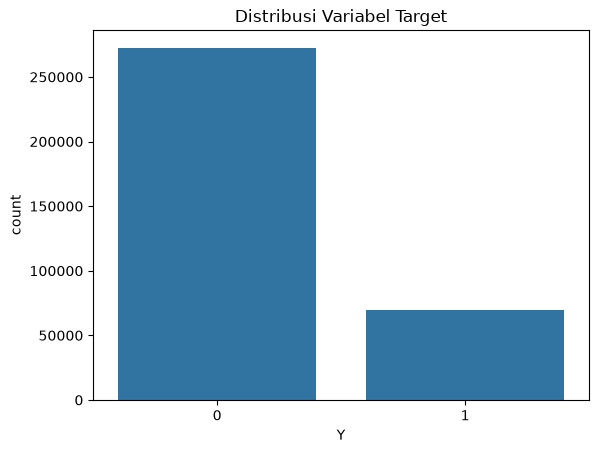

In [4]:
# Distribusi target
print(df['Y'].value_counts())
print(df['Y'].value_counts(normalize=True))  # Cek imbalance ratio

# Visualisasi
sns.countplot(data=df, x='Y')
plt.title('Distribusi Variabel Target')
plt.show()

B. Eksplorasi Hubungan Y dengan X


=== Crosstab: X1 vs Y ===
Y         0      1     All
X1                        
1    119721  23694  143415
2    152704  45683  198387
All  272425  69377  341802
Chi-square p-value: 0.0000


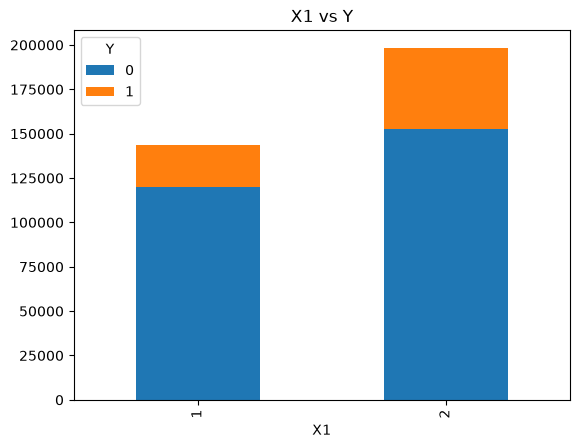


=== Crosstab: X2 vs Y ===
Y         0      1     All
X2                        
1    232428  58033  290461
2     11740   2949   14689
3     24224   8009   32233
4      3955    335    4290
5        78     51     129
All  272425  69377  341802
Chi-square p-value: 0.0000


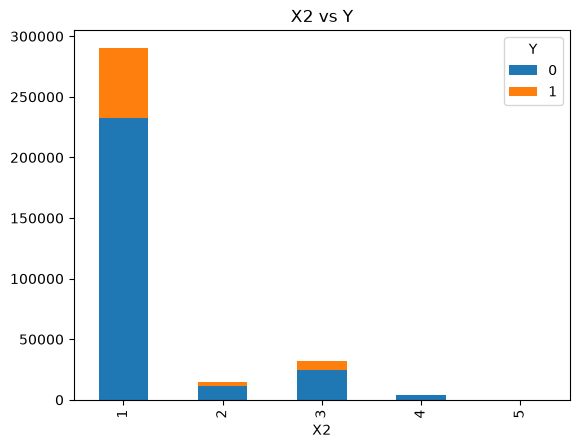


=== Crosstab: X3 vs Y ===
Y         0      1     All
X3                        
0    242884  64998  307882
1     29541   4379   33920
All  272425  69377  341802
Chi-square p-value: 0.0000


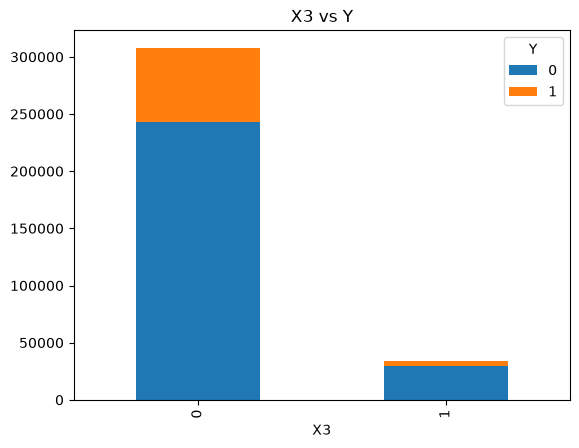


=== Crosstab: X4 vs Y ===
Y         0      1     All
X4                        
0    243094  67235  310329
1     29331   2142   31473
All  272425  69377  341802
Chi-square p-value: 0.0000


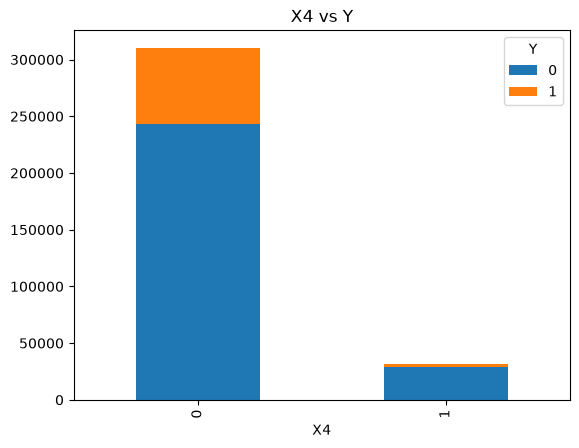


=== Crosstab: X5 vs Y ===
Y         0      1     All
X5                        
0     88767  39238  128005
1    183658  30139  213797
All  272425  69377  341802
Chi-square p-value: 0.0000


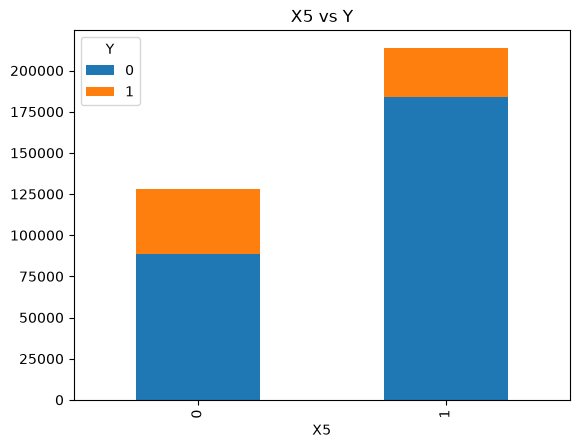


=== Crosstab: X6 vs Y ===
Y         0      1     All
X6                        
0    245710  68270  313980
1     26715   1107   27822
All  272425  69377  341802
Chi-square p-value: 0.0000


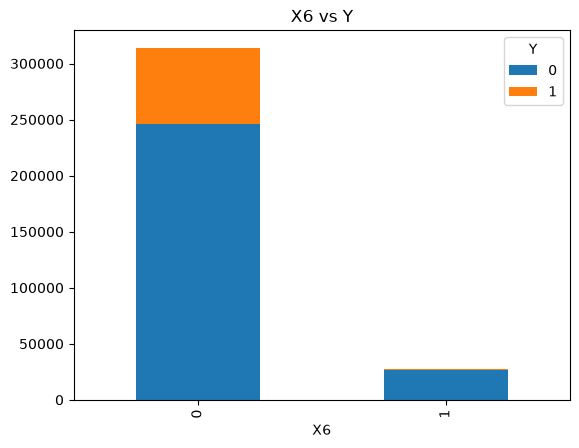


=== Crosstab: X7 vs Y ===
Y         0      1     All
X7                        
0    267917  69152  337069
1      4508    225    4733
All  272425  69377  341802
Chi-square p-value: 0.0000


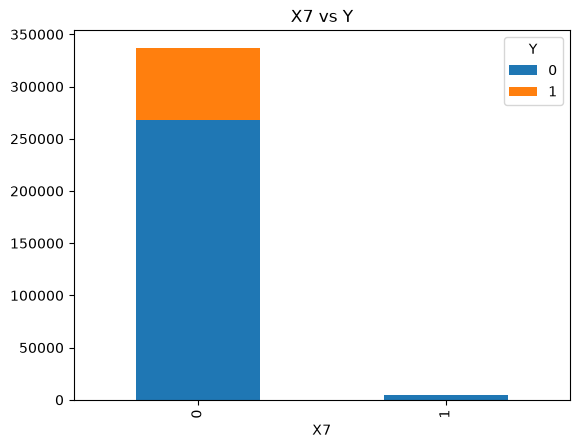


=== Crosstab: X8 vs Y ===
Y         0      1     All
X8                        
0    269885  69241  339126
1      2540    136    2676
All  272425  69377  341802
Chi-square p-value: 0.0000


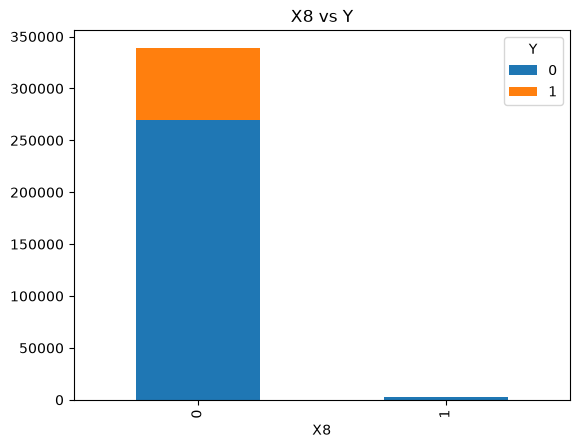


=== Crosstab: X9 vs Y ===
Y         0      1     All
X9                        
0    224442  65746  290188
1     47983   3631   51614
All  272425  69377  341802
Chi-square p-value: 0.0000


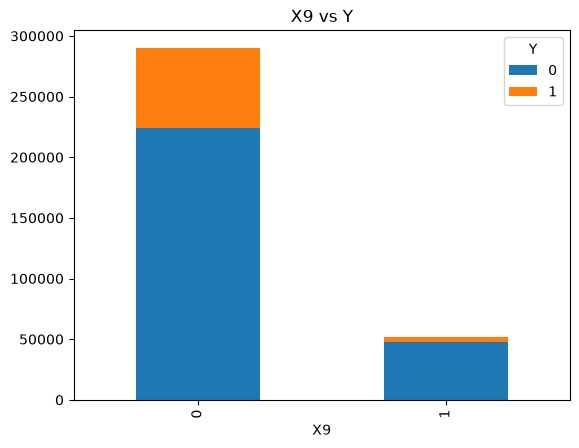


=== Crosstab: X10 vs Y ===
Y         0      1     All
X10                       
0    218387  65713  284100
1     54038   3664   57702
All  272425  69377  341802
Chi-square p-value: 0.0000


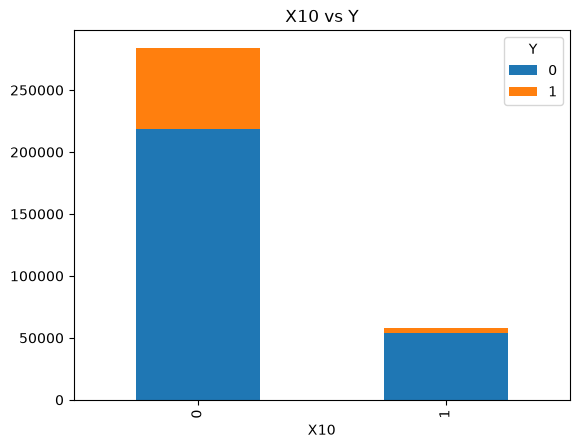


=== Crosstab: X11 vs Y ===
Y         0      1     All
X11                       
0     57043  25760   82803
1    215382  43617  258999
All  272425  69377  341802
Chi-square p-value: 0.0000


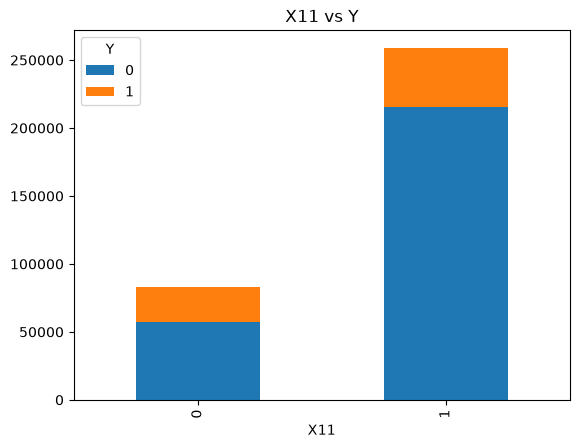


=== Crosstab: X12 vs Y ===
Y         0      1     All
X12                       
0    232636  67271  299907
1     39789   2106   41895
All  272425  69377  341802
Chi-square p-value: 0.0000


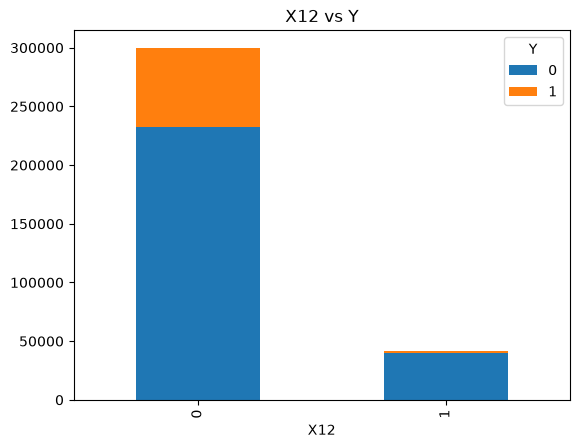


=== Crosstab: X13 vs Y ===
Y         0      1     All
X13                       
1    155850  28742  184592
5    116575  40635  157210
All  272425  69377  341802
Chi-square p-value: 0.0000


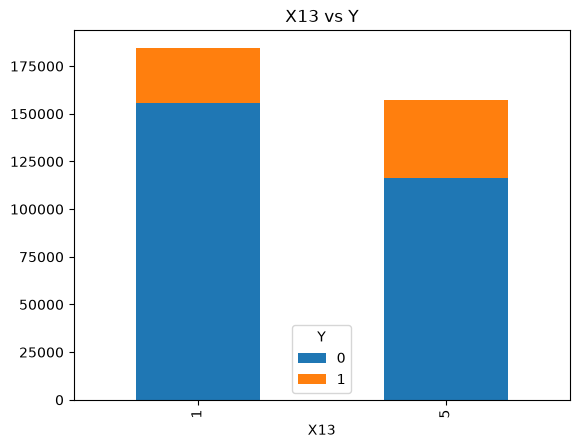


=== Crosstab: X14 vs Y ===
Y         0      1     All
X14                       
0     43601  17416   61017
1     74449  22879   97328
2     45172  11759   56931
3     77854  14547   92401
4      5793    507    6300
5     23335   2208   25543
6      2221     61    2282
All  272425  69377  341802
Chi-square p-value: 0.0000


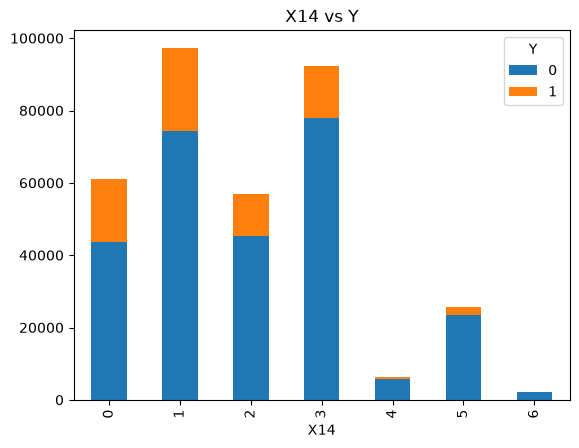


=== Crosstab: X15 vs Y ===
Y         0      1     All
X15                       
1    236448  58139  294587
2     35977  11238   47215
All  272425  69377  341802
Chi-square p-value: 0.0000


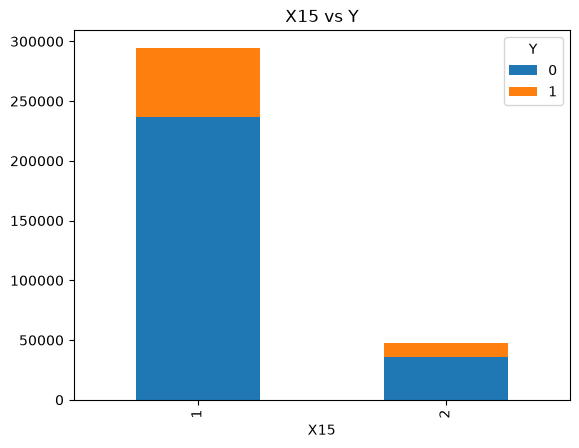


=== Crosstab: X16 vs Y ===
Y         0      1     All
X16                       
0     28036   8116   36152
1    106381  32909  139290
2     44808  11529   56337
3     93200  16823  110023
All  272425  69377  341802
Chi-square p-value: 0.0000


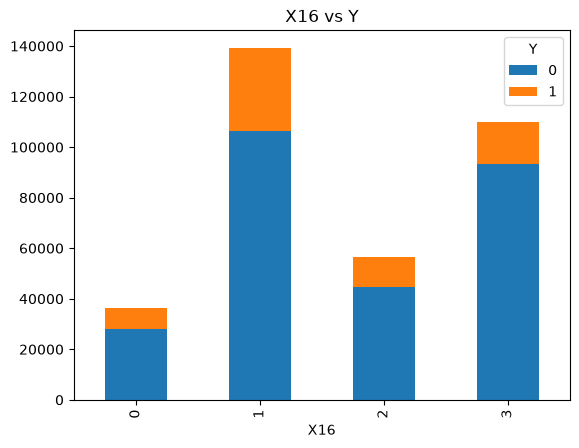


=== Crosstab: X17 vs Y ===
Y         0      1     All
X17                       
0    214750  64198  278948
1     57675   5179   62854
All  272425  69377  341802
Chi-square p-value: 0.0000


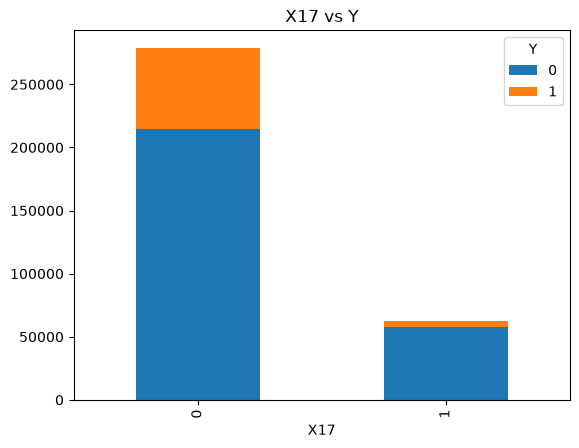

In [5]:
# Untuk setiap variabel kategorik X
for col in df.columns:
    if col != 'Y':  # Changed 'target' to 'Y'
        # Crosstab
        ct = pd.crosstab(df[col], df['Y'], margins=True) # Changed 'target' to 'Y'
        print(f"\n=== Crosstab: {col} vs Y ===") # Changed 'Target' to 'Y'
        print(ct)

        # Chi-square test
        from scipy.stats import chi2_contingency
        # Ensure that ct has at least 2x2 dimensions before applying chi2_contingency
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p, dof, expected = chi2_contingency(ct.iloc[:-1, :-1])
            print(f"Chi-square p-value: {p:.4f}")
        else:
            print("Cannot perform Chi-square test: insufficient dimensions in crosstab.")

        # Visualisasi
        pd.crosstab(df[col], df['Y']).plot(kind='bar', stacked=True) # Changed 'target' to 'Y'
        plt.title(f'{col} vs Y') # Changed 'Target' to 'Y'
        plt.show()

C. Ringkasan Statistik

In [6]:
df.describe(include='all')
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 341802 entries, 0 to 341801
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   X1      341802 non-null  int64
 1   X2      341802 non-null  int64
 2   X3      341802 non-null  int64
 3   X4      341802 non-null  int64
 4   X5      341802 non-null  int64
 5   X6      341802 non-null  int64
 6   X7      341802 non-null  int64
 7   X8      341802 non-null  int64
 8   X9      341802 non-null  int64
 9   X10     341802 non-null  int64
 10  X11     341802 non-null  int64
 11  X12     341802 non-null  int64
 12  X13     341802 non-null  int64
 13  X14     341802 non-null  int64
 14  X15     341802 non-null  int64
 15  X16     341802 non-null  int64
 16  X17     341802 non-null  int64
 17  Y       341802 non-null  int64
dtypes: int64(18)
memory usage: 46.9 MB


X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
Y      0
dtype: int64

#3. Data Preprocessing (OHE)

In [7]:
# Pisahkan X dan y
X = df.drop('Y', axis=1)
y = df['Y']

# One-Hot Encoding SEMUA variabel kategorik
# (karena semua X adalah kategorik)
X_encoded = pd.get_dummies(X, drop_first=True)  # drop_first=True untuk menghindari dummy trap

print(f"Shape setelah OHE: {X_encoded.shape}")
print(f"Jumlah fitur: {X_encoded.shape[1]}")

Shape setelah OHE: (341802, 17)
Jumlah fitur: 17


#4. Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Penting! Agar proporsi kelas tetap sama
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")
print(f"\nDistribusi Training:\n{y_train.value_counts(normalize=True)}")

Training set: (273441, 17)
Testing set: (68361, 17)

Distribusi Training:
Y
0    0.797028
1    0.202972
Name: proportion, dtype: float64


#5. Penanganan Imbalanced Data

menentukan metode penanganan imbalance dengan model random forest

In [9]:
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

methods = {
    'TANPA RESAMPLING': None,
    'ROS': RandomOverSampler(random_state=42),
    'RUS': RandomUnderSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

model = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'recall':    'recall',
    'precision': 'precision',
    'f1':        'f1',
    'roc_auc':   'roc_auc'
}

results = []

for name, sampler in methods.items():
    if sampler is None:
        X_res, y_res = X_train, y_train
    else:
        X_res, y_res = sampler.fit_resample(X_train, y_train)

    scores = cross_validate(model, X_res, y_res,
                            cv=cv, scoring=scoring, n_jobs=-1)

    results.append({
        'Method':    name,
        'Accuracy':  scores['test_accuracy'].mean(),
        'Recall':    scores['test_recall'].mean(),
        'Precision': scores['test_precision'].mean(),
        'F1-Score':  scores['test_f1'].mean(),
        'ROC-AUC':   scores['test_roc_auc'].mean()
    })

df_results = pd.DataFrame(results)
print(df_results.round(4))

             Method  Accuracy  Recall  Precision  F1-Score  ROC-AUC
0  TANPA RESAMPLING    0.7912  0.0248     0.3162    0.0460   0.6737
1               ROS    0.6614  0.7482     0.6376    0.6885   0.7234
2               RUS    0.6297  0.7011     0.6135    0.6543   0.6702
3             SMOTE    0.6603  0.7606     0.6335    0.6912   0.7185
4            ADASYN    0.6475  0.7399     0.6130    0.6705   0.7067


Karena f1 dan recall yang paling besar dengan metode **SMOTE** maka penanganan imbalance menggunakan metode tsb

SMOTE dipilih daripada ROS karena meskipun keduanya meningkatkan jumlah sample kelas minoritas, SMOTE menghasilkan sample synthetic baru yang menambah variasi data, bukan sekadar menduplikasi data existing. Hal ini mengurangi risiko overfitting dan menghasilkan model yang lebih generalizable, terbukti dari F1-Score SMOTE (0.6912) > ROS (0.6885) dan Recall SMOTE (76.06%) > ROS (74.82%).

In [10]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

#6. Explanatory Modelling - Logistic Regression

A. Training Model

In [11]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_res, y_train_res)

print("✓ Logistic Regression training selesai")

✓ Logistic Regression training selesai


B. Interpretasi Koefisien

In [12]:
# Tambah konstanta (intercept)
X_train_const = sm.add_constant(X_train_res)

# Fit model dengan statsmodels
logit_model = sm.Logit(y_train_res, X_train_const)
result = logit_model.fit(disp=0)

print("\n" + "="*70)
print("SUMMARY LOGISTIC REGRESSION (Statsmodels)")
print("="*70)
print(result.summary())


SUMMARY LOGISTIC REGRESSION (Statsmodels)
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:               435880
Model:                          Logit   Df Residuals:                   435862
Method:                           MLE   Df Model:                           17
Date:                Sat, 13 Jun 2026   Pseudo R-squ.:                  0.1064
Time:                        16:41:34   Log-Likelihood:            -2.6999e+05
converged:                       True   LL-Null:                   -3.0213e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5202      0.027     18.959      0.000       0.466       0.574
X1            -0.0413      0.008     -5.459      0.000      -0.056      -0.026
X2       

C. IDENTIFIKASI VARIABEL SIGNIFIKAN

In [13]:
summary_table = pd.DataFrame({
    'Variable': result.params.index,
    'Coefficient': result.params.values,
    'Std_Error': result.bse.values,
    'z_value': result.tvalues.values,
    'p_value': result.pvalues.values,
    'Odds_Ratio': np.exp(result.params.values)
})

# Variabel signifikan pada α = 5%
signifikan = summary_table[summary_table['p_value'] < 0.05].sort_values('p_value')

print("\n" + "="*70)
print("VARIABEL SIGNIFIKAN pada taraf signifikansi 5% (α = 0.05)")
print("="*70)
print(signifikan[['Variable', 'Coefficient', 'p_value', 'Odds_Ratio']])
print(f"\nJumlah variabel signifikan: {len(signifikan)} dari {len(summary_table)-1} fitur")

# Variabel TIDAK signifikan (untuk referensi)
tidak_signifikan = summary_table[summary_table['p_value'] >= 0.05].sort_values('p_value')
print("\n" + "-"*50)
print("VARIABEL TIDAK SIGNIFIKAN (p >= 0.05):")
print(tidak_signifikan[['Variable', 'p_value']])


VARIABEL SIGNIFIKAN pada taraf signifikansi 5% (α = 0.05)
   Variable  Coefficient        p_value  Odds_Ratio
5        X5    -0.460023   0.000000e+00    0.631269
12      X12    -0.741545   0.000000e+00    0.476377
10      X10    -0.838726   0.000000e+00    0.432261
11      X11    -0.311329   0.000000e+00    0.732473
4        X4    -0.657310  1.764659e-288    0.518243
6        X6    -0.769374  4.234077e-221    0.463303
9        X9    -0.407983  4.753540e-195    0.664990
17      X17    -0.347263  1.570247e-192    0.706620
13      X13     0.045370  1.270098e-153    1.046415
3        X3    -0.315072  7.515369e-127    0.729736
14      X14    -0.063268  4.381782e-114    0.938692
0     const     0.520171   3.688757e-80    1.682314
7        X7    -1.088870   1.388421e-52    0.336597
15      X15     0.141331   1.448733e-36    1.151806
8        X8    -1.272898   6.935831e-35    0.280019
2        X2     0.054527   1.885106e-28    1.056040
16      X16     0.037837   5.787417e-20    1.038562
1    

D. PREDIKSI pada TEST SET

In [14]:
y_pred_logreg = logreg.predict(X_test)
y_pred_proba_logreg = logreg.predict_proba(X_test)[:, 1]

E. CONFUSION MATRIX


CONFUSION MATRIX - Logistic Regression
[[30043 24442]
 [ 3760 10116]]


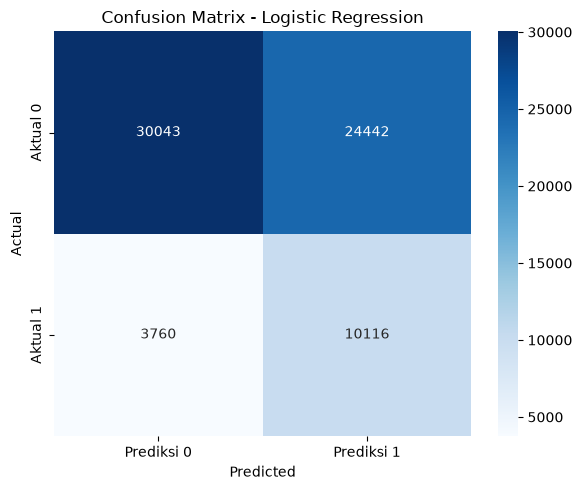

In [15]:
cm = confusion_matrix(y_test, y_pred_logreg)

print("\n" + "="*70)
print("CONFUSION MATRIX - Logistic Regression")
print("="*70)
print(cm)

# Visualisasi
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

F. EVALUASI PERFORMANCE

In [16]:
print("\n" + "="*70)
print("EVALUASI PERFORMANCE - Logistic Regression")
print("="*70)

acc = accuracy_score(y_test, y_pred_logreg)
rec = recall_score(y_test, y_pred_logreg)
prec = precision_score(y_test, y_pred_logreg)
f1 = f1_score(y_test, y_pred_logreg)
roc = roc_auc_score(y_test, y_pred_proba_logreg)

print(f"Accuracy : {acc:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")

print("\n" + "-"*50)
print("Classification Report:")
print(classification_report(y_test, y_pred_logreg))


EVALUASI PERFORMANCE - Logistic Regression
Accuracy : 0.5875
Recall   : 0.7290
Precision: 0.2927
F1-Score : 0.4177
ROC-AUC  : 0.6933

--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.55      0.68     54485
           1       0.29      0.73      0.42     13876

    accuracy                           0.59     68361
   macro avg       0.59      0.64      0.55     68361
weighted avg       0.77      0.59      0.63     68361



G. ROC CURVE

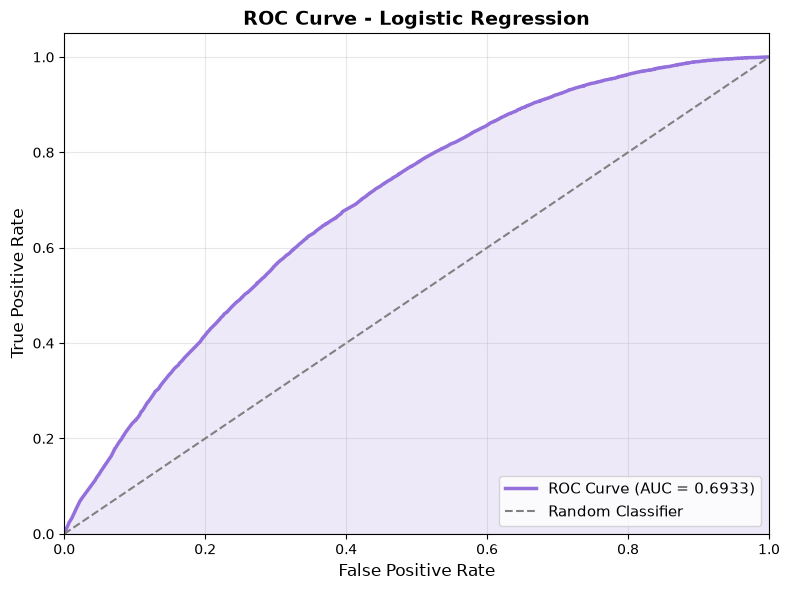

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#9370DB', lw=2.5,
         label=f'ROC Curve (AUC = {roc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--',
         label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.15, color='#9370DB')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

H. SIMPAN HASIL

In [18]:
hasil_logreg = {
    'Model': 'Logistic Regression',
    'Accuracy': acc,
    'Recall': rec,
    'Precision': prec,
    'F1-Score': f1,
    'ROC-AUC': roc
}

print("\n" + "="*70)
print("HASIL TERSIMPAN")
print("="*70)
for key, value in hasil_logreg.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


HASIL TERSIMPAN
Model: Logistic Regression
Accuracy: 0.5875
Recall: 0.7290
Precision: 0.2927
F1-Score: 0.4177
ROC-AUC: 0.6933


#7. Predictive Modelling

A. Random Forest

✓ Random Forest training selesai


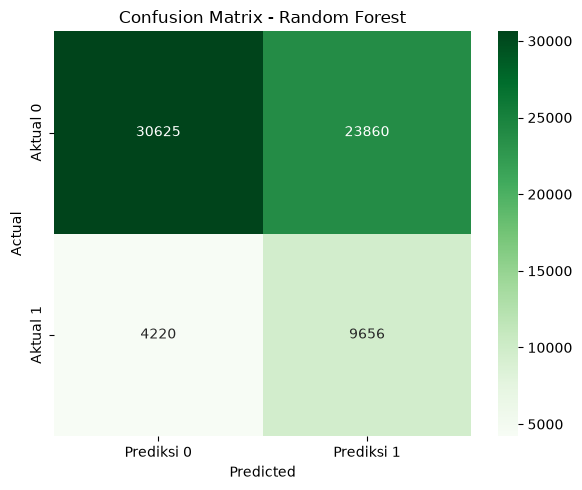

Confusion Matrix - Random Forest:
[[30625 23860]
 [ 4220  9656]]

EVALUASI - Random Forest
Accuracy : 0.5892
Recall   : 0.6959
Precision: 0.2881
F1-Score : 0.4075
ROC-AUC  : 0.6752

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.56      0.69     54485
           1       0.29      0.70      0.41     13876

    accuracy                           0.59     68361
   macro avg       0.58      0.63      0.55     68361
weighted avg       0.76      0.59      0.63     68361



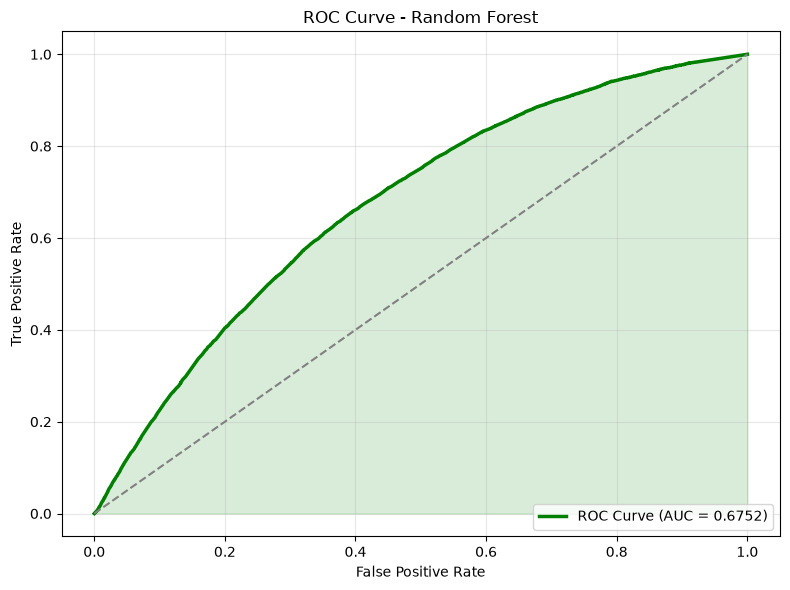

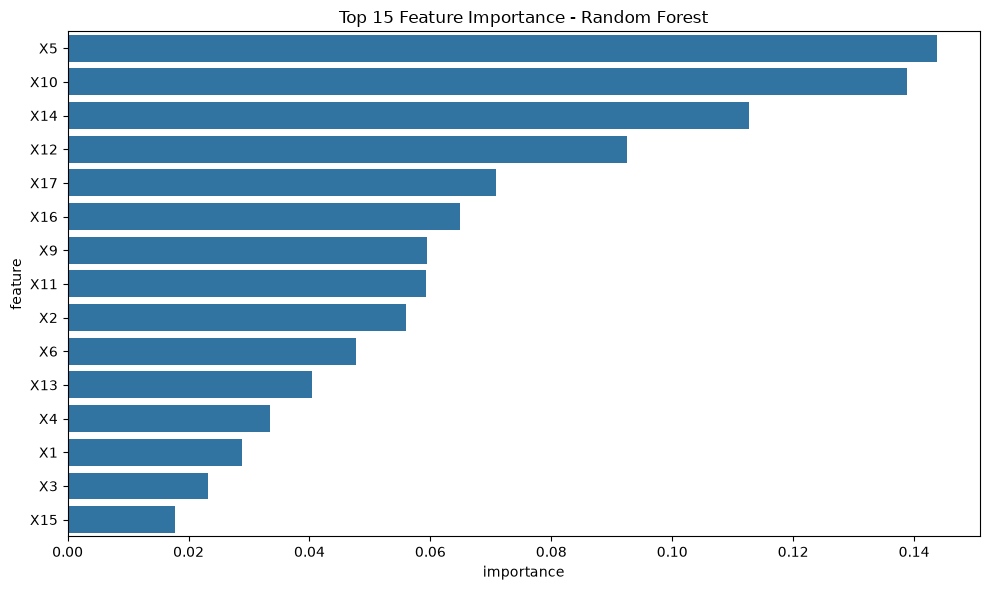

In [19]:
# ============================================================
# PREDICTIVE MODELLING 1: RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1A. TRAINING MODEL
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

print("✓ Random Forest training selesai")

# 1B. PREDIKSI pada TEST SET
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# 1C. CONFUSION MATRIX
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix - Random Forest:")
print(cm_rf)

# 1D. EVALUASI PERFORMANCE
acc_rf = accuracy_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\n" + "="*50)
print("EVALUASI - Random Forest")
print("="*50)
print(f"Accuracy : {acc_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 1E. ROC CURVE
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2.5,
         label=f'ROC Curve (AUC = {roc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.15, color='green')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 1F. FEATURE IMPORTANCE
importances_rf = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_rf.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

# 1G. SIMPAN HASIL
hasil_rf = {
    'Model': 'Random Forest',
    'Accuracy': acc_rf,
    'Recall': rec_rf,
    'Precision': prec_rf,
    'F1-Score': f1_rf,
    'ROC-AUC': roc_rf
}

B. XGBoost

✓ XGBoost training selesai


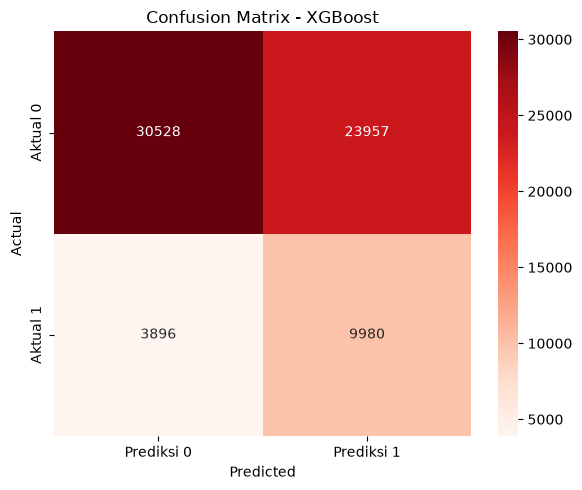

Confusion Matrix - XGBoost:
[[30528 23957]
 [ 3896  9980]]

EVALUASI - XGBoost
Accuracy : 0.5926
Recall   : 0.7192
Precision: 0.2941
F1-Score : 0.4175
ROC-AUC  : 0.6924

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.56      0.69     54485
           1       0.29      0.72      0.42     13876

    accuracy                           0.59     68361
   macro avg       0.59      0.64      0.55     68361
weighted avg       0.77      0.59      0.63     68361



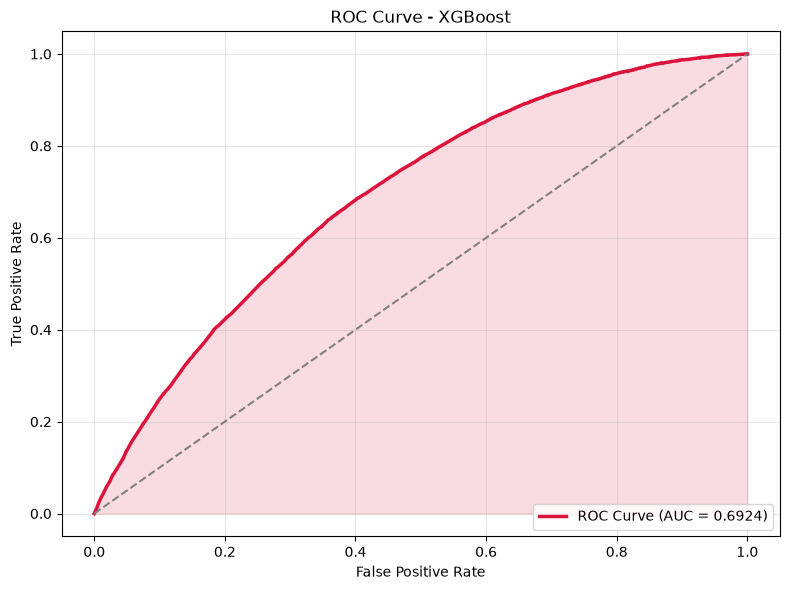

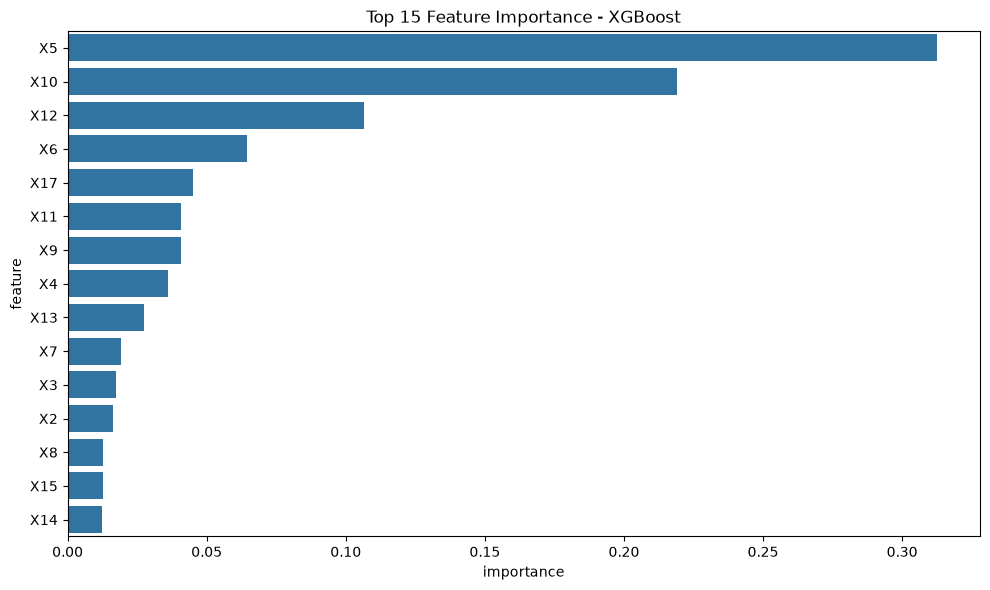

In [20]:
# ============================================================
# PREDICTIVE MODELLING 2: XGBOOST
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 3A. TRAINING MODEL
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

print("✓ XGBoost training selesai")

# 3B. PREDIKSI pada TEST SET
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# 3C. CONFUSION MATRIX
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix - XGBoost:")
print(cm_xgb)

# 3D. EVALUASI PERFORMANCE
acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n" + "="*50)
print("EVALUASI - XGBoost")
print("="*50)
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"F1-Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# 3E. ROC CURVE
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='crimson', lw=2.5,
         label=f'ROC Curve (AUC = {roc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_xgb, tpr_xgb, alpha=0.15, color='crimson')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3F. FEATURE IMPORTANCE
importances_xgb = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_xgb.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

# 3G. SIMPAN HASIL
hasil_xgb = {
    'Model': 'XGBoost',
    'Accuracy': acc_xgb,
    'Recall': rec_xgb,
    'Precision': prec_xgb,
    'F1-Score': f1_xgb,
    'ROC-AUC': roc_xgb
}

C. LightGBM

✓ LightGBM training selesai


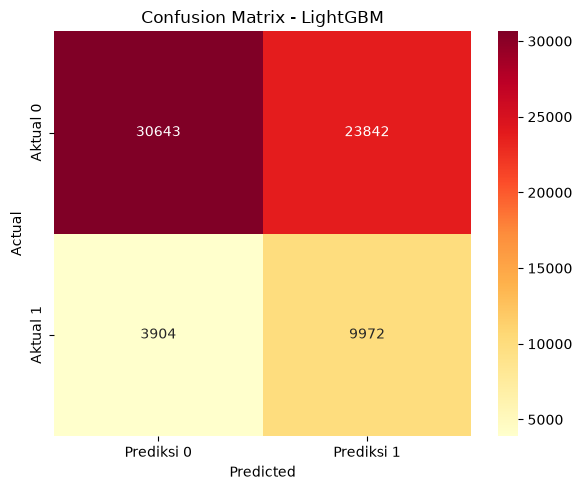

Confusion Matrix - LightGBM:
[[30643 23842]
 [ 3904  9972]]

EVALUASI - LightGBM
Accuracy : 0.5941
Recall   : 0.7187
Precision: 0.2949
F1-Score : 0.4182
ROC-AUC  : 0.6945

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.56      0.69     54485
           1       0.29      0.72      0.42     13876

    accuracy                           0.59     68361
   macro avg       0.59      0.64      0.55     68361
weighted avg       0.77      0.59      0.63     68361



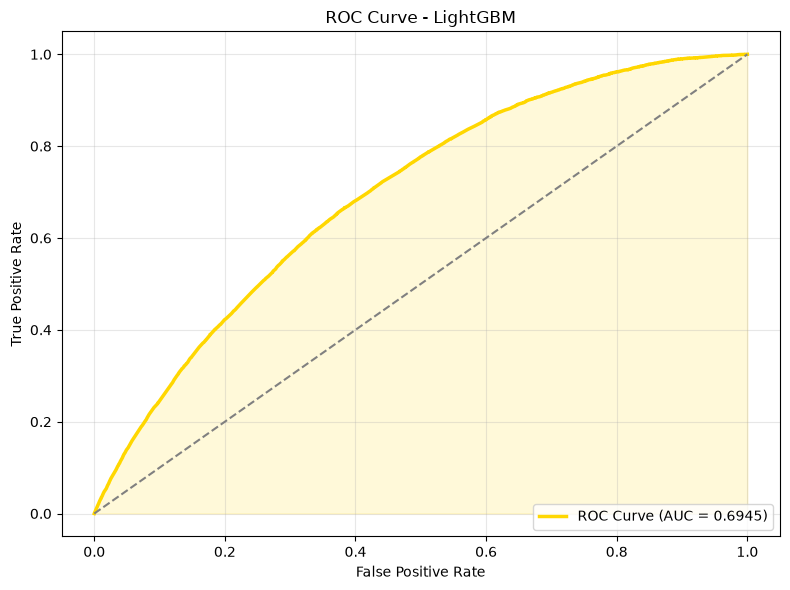

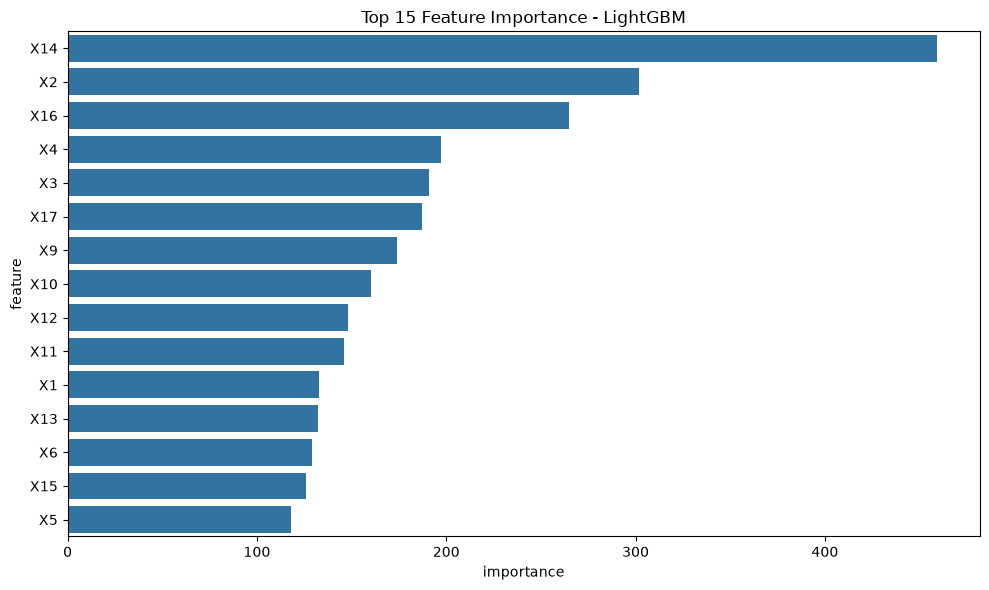

In [21]:
# ============================================================
# PREDICTIVE MODELLING 4: LIGHTGBM
# ============================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 4A. TRAINING MODEL
lgbm = LGBMClassifier(random_state=42, verbose=-1)
lgbm.fit(X_train_res, y_train_res)

print("✓ LightGBM training selesai")

# 4B. PREDIKSI pada TEST SET
y_pred_lgbm = lgbm.predict(X_test)
y_pred_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]

# 4C. CONFUSION MATRIX
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - LightGBM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix - LightGBM:")
print(cm_lgbm)

# 4D. EVALUASI PERFORMANCE
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
rec_lgbm = recall_score(y_test, y_pred_lgbm)
prec_lgbm = precision_score(y_test, y_pred_lgbm)
f1_lgbm = f1_score(y_test, y_pred_lgbm)
roc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)

print("\n" + "="*50)
print("EVALUASI - LightGBM")
print("="*50)
print(f"Accuracy : {acc_lgbm:.4f}")
print(f"Recall   : {rec_lgbm:.4f}")
print(f"Precision: {prec_lgbm:.4f}")
print(f"F1-Score : {f1_lgbm:.4f}")
print(f"ROC-AUC  : {roc_lgbm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))

# 4E. ROC CURVE
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_proba_lgbm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lgbm, tpr_lgbm, color='gold', lw=2.5,
         label=f'ROC Curve (AUC = {roc_lgbm:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_lgbm, tpr_lgbm, alpha=0.15, color='gold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4F. FEATURE IMPORTANCE
importances_lgbm = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': lgbm.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_lgbm.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

# 4G. SIMPAN HASIL
hasil_lgbm = {
    'Model': 'LightGBM',
    'Accuracy': acc_lgbm,
    'Recall': rec_lgbm,
    'Precision': prec_lgbm,
    'F1-Score': f1_lgbm,
    'ROC-AUC': roc_lgbm
}

D. CatBoost

✓ CatBoost training selesai


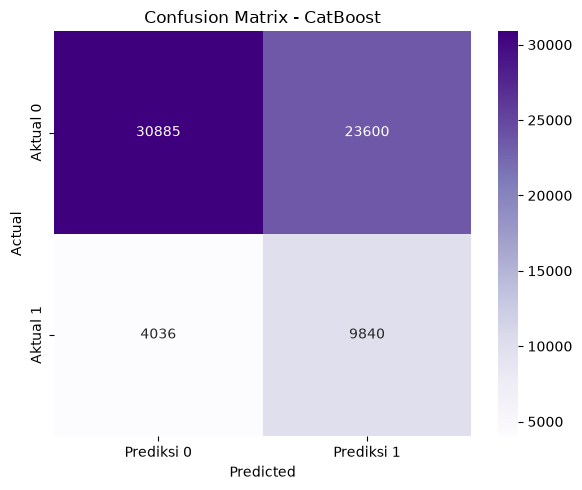

Confusion Matrix - CatBoost:
[[30885 23600]
 [ 4036  9840]]

EVALUASI - CatBoost
Accuracy : 0.5957
Recall   : 0.7091
Precision: 0.2943
F1-Score : 0.4159
ROC-AUC  : 0.6898

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     54485
           1       0.29      0.71      0.42     13876

    accuracy                           0.60     68361
   macro avg       0.59      0.64      0.55     68361
weighted avg       0.76      0.60      0.64     68361



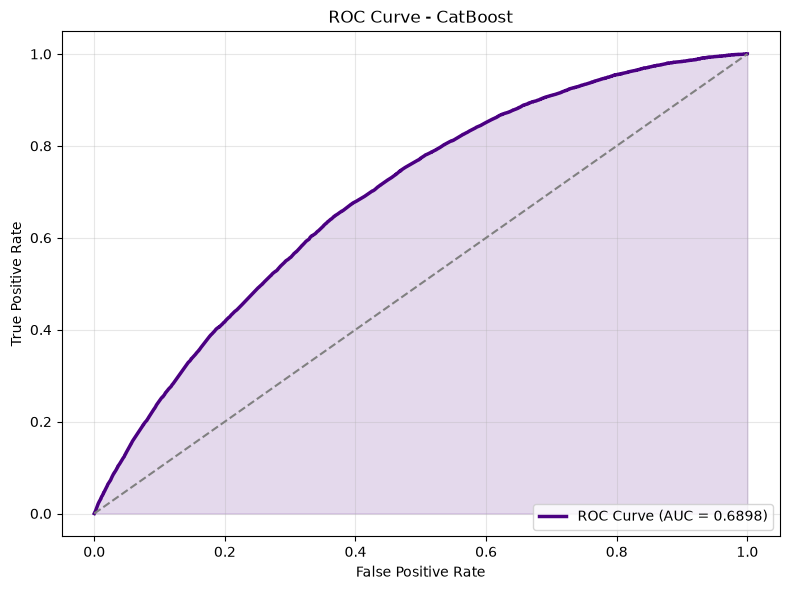

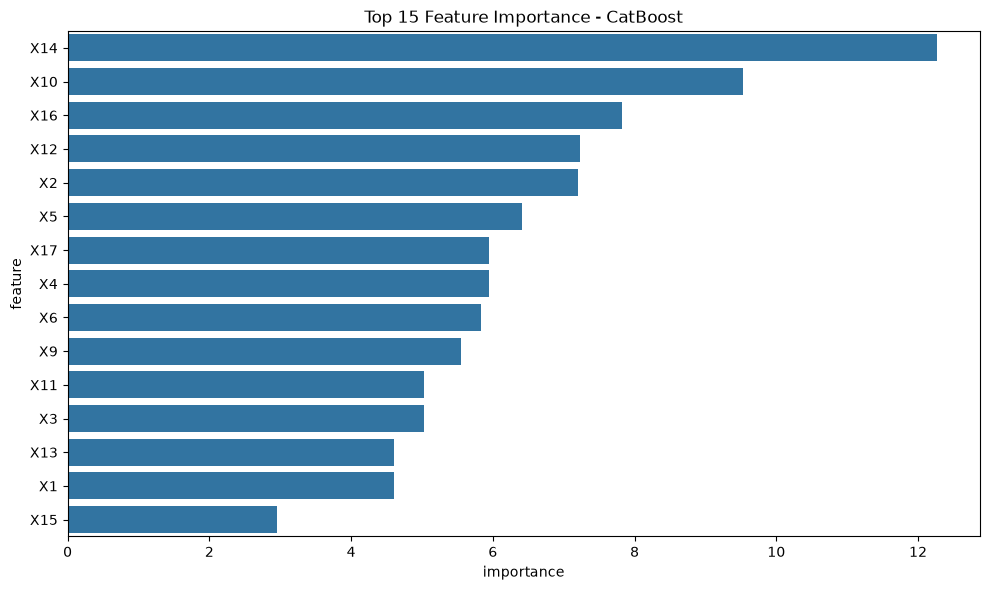

In [22]:
# ============================================================
# PREDICTIVE MODELLING 5: CATBOOST
# ============================================================

from catboost import CatBoostClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 5A. TRAINING MODEL
catboost = CatBoostClassifier(random_state=42, verbose=0)
catboost.fit(X_train_res, y_train_res)

print("✓ CatBoost training selesai")

# 5B. PREDIKSI pada TEST SET
y_pred_cat = catboost.predict(X_test)
y_pred_proba_cat = catboost.predict_proba(X_test)[:, 1]

# 5C. CONFUSION MATRIX
cm_cat = confusion_matrix(y_test, y_pred_cat)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - CatBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix - CatBoost:")
print(cm_cat)

# 5D. EVALUASI PERFORMANCE
acc_cat = accuracy_score(y_test, y_pred_cat)
rec_cat = recall_score(y_test, y_pred_cat)
prec_cat = precision_score(y_test, y_pred_cat)
f1_cat = f1_score(y_test, y_pred_cat)
roc_cat = roc_auc_score(y_test, y_pred_proba_cat)

print("\n" + "="*50)
print("EVALUASI - CatBoost")
print("="*50)
print(f"Accuracy : {acc_cat:.4f}")
print(f"Recall   : {rec_cat:.4f}")
print(f"Precision: {prec_cat:.4f}")
print(f"F1-Score : {f1_cat:.4f}")
print(f"ROC-AUC  : {roc_cat:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))

# 5E. ROC CURVE
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_pred_proba_cat)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cat, tpr_cat, color='indigo', lw=2.5,
         label=f'ROC Curve (AUC = {roc_cat:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_cat, tpr_cat, alpha=0.15, color='indigo')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CatBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5F. FEATURE IMPORTANCE
importances_cat = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': catboost.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_cat.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - CatBoost')
plt.tight_layout()
plt.show()

# 5G. SIMPAN HASIL
hasil_cat = {
    'Model': 'CatBoost',
    'Accuracy': acc_cat,
    'Recall': rec_cat,
    'Precision': prec_cat,
    'F1-Score': f1_cat,
    'ROC-AUC': roc_cat
}

E. SVM

⚡ Sampling SVM: 435880 → 43588 baris (10%)
Distribusi kelas setelah sampling:
Y
1    21856
0    21732
Name: count, dtype: int64


d:\Downloads\KULIAH Intan\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
d:\Downloads\KULIAH Intan\.venv\Lib\site-packages\sklearn\svm\_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


✓ SVM training selesai


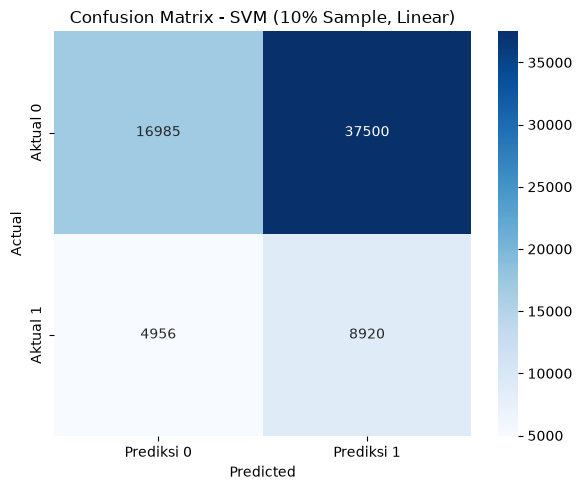

Confusion Matrix - SVM:
[[16985 37500]
 [ 4956  8920]]

EVALUASI - SVM (10% Sample, Linear Kernel)
Accuracy : 0.3789
Recall   : 0.6428
Precision: 0.1922
F1-Score : 0.2959
ROC-AUC  : 0.4607

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.31      0.44     54485
           1       0.19      0.64      0.30     13876

    accuracy                           0.38     68361
   macro avg       0.48      0.48      0.37     68361
weighted avg       0.66      0.38      0.41     68361



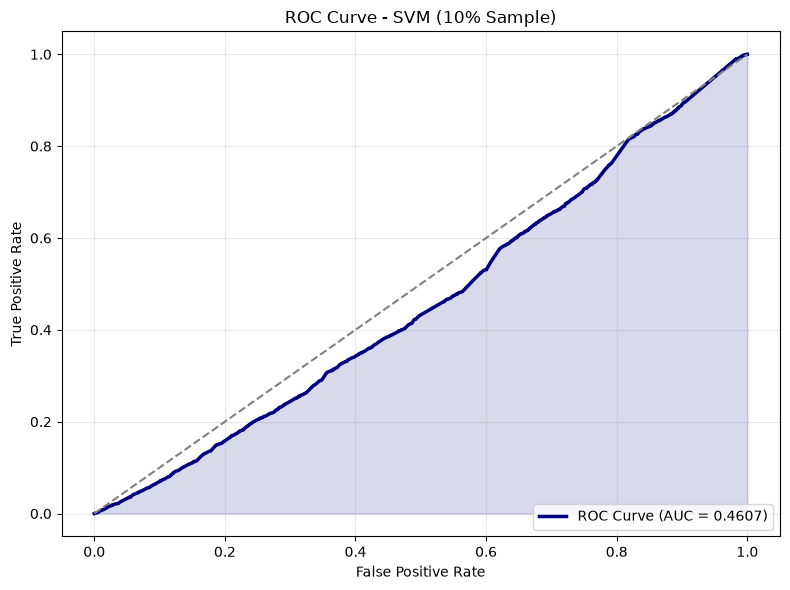


✓ Hasil SVM tersimpan


In [23]:
# ============================================================
# PREDICTIVE MODELLING 6: SVM (DENGAN SAMPLING 10%)
# ============================================================

from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------------
# 6A. SAMPLING DATA TRAINING (10% dari X_train_res)
# ------------------------------------------------------------
# Ambil 10% sample dari data hasil SMOTE

sample_size = int(len(X_train_res) * 0.10)  # 10% dari total data

X_train_svm = X_train_res.sample(n=sample_size, random_state=42)
y_train_svm = y_train_res.loc[X_train_svm.index]

print(f"⚡ Sampling SVM: {len(X_train_res)} → {sample_size} baris (10%)")
print(f"Distribusi kelas setelah sampling:\n{pd.Series(y_train_svm).value_counts()}")

# ------------------------------------------------------------
# 6B. TRAINING SVM (Linear kernel untuk kecepatan)
# ------------------------------------------------------------
svm = SVC(
    kernel='linear',
    C=1.0,
    max_iter=2000,
    random_state=42,
    probability=True
)

svm.fit(X_train_svm, y_train_svm)
print("✓ SVM training selesai")

# ------------------------------------------------------------
# 6C. PREDIKSI pada TEST SET (X_test tetap utuh!)
# ------------------------------------------------------------
y_pred_svm = svm.predict(X_test)
y_pred_proba_svm = svm.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 6D. CONFUSION MATRIX
# ------------------------------------------------------------
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - SVM (10% Sample, Linear)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix - SVM:")
print(cm_svm)

# ------------------------------------------------------------
# 6E. EVALUASI PERFORMANCE
# ------------------------------------------------------------
acc_svm = accuracy_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_svm = roc_auc_score(y_test, y_pred_proba_svm)

print("\n" + "="*50)
print("EVALUASI - SVM (10% Sample, Linear Kernel)")
print("="*50)
print(f"Accuracy : {acc_svm:.4f}")
print(f"Recall   : {rec_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")
print(f"ROC-AUC  : {roc_svm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# ------------------------------------------------------------
# 6F. ROC CURVE
# ------------------------------------------------------------
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='navy', lw=2.5,
         label=f'ROC Curve (AUC = {roc_svm:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_svm, tpr_svm, alpha=0.15, color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (10% Sample)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6G. SIMPAN HASIL
# ------------------------------------------------------------
hasil_svm = {
    'Model': 'SVM (Linear, 10% Sample)',
    'Accuracy': acc_svm,
    'Recall': rec_svm,
    'Precision': prec_svm,
    'F1-Score': f1_svm,
    'ROC-AUC': roc_svm
}

print("\n✓ Hasil SVM tersimpan")

F. Gradient Boosting

✓ Gradient Boosting training selesai


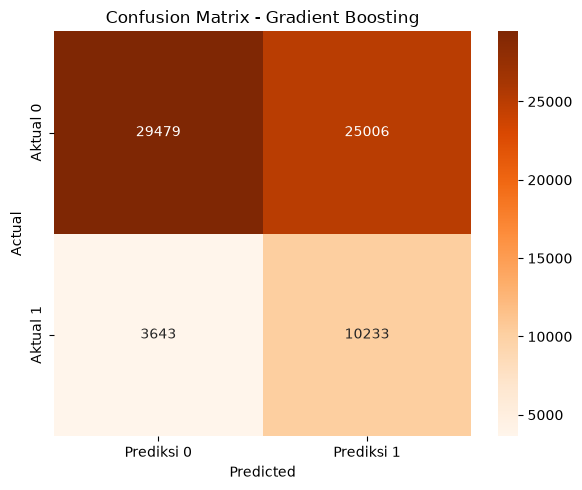

Confusion Matrix - Gradient Boosting:
[[29479 25006]
 [ 3643 10233]]

EVALUASI - Gradient Boosting
Accuracy : 0.5809
Recall   : 0.7375
Precision: 0.2904
F1-Score : 0.4167
ROC-AUC  : 0.6950

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.54      0.67     54485
           1       0.29      0.74      0.42     13876

    accuracy                           0.58     68361
   macro avg       0.59      0.64      0.54     68361
weighted avg       0.77      0.58      0.62     68361



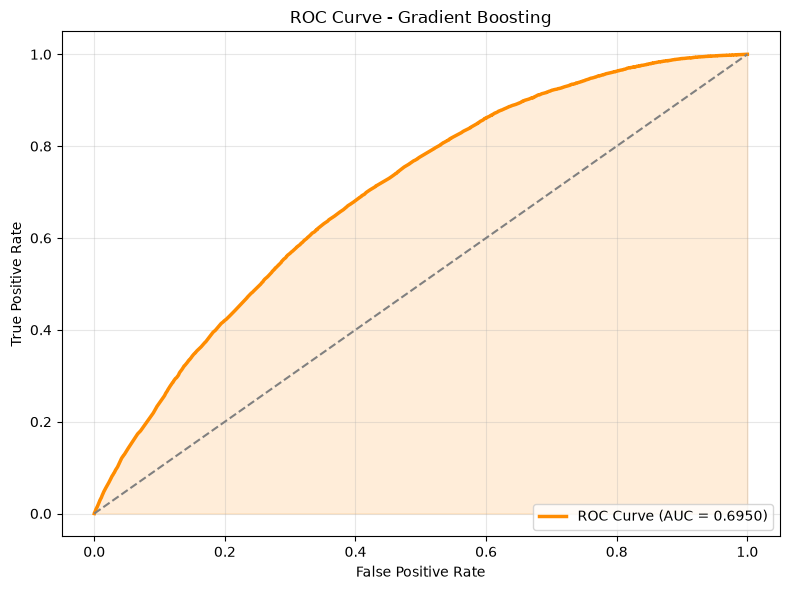

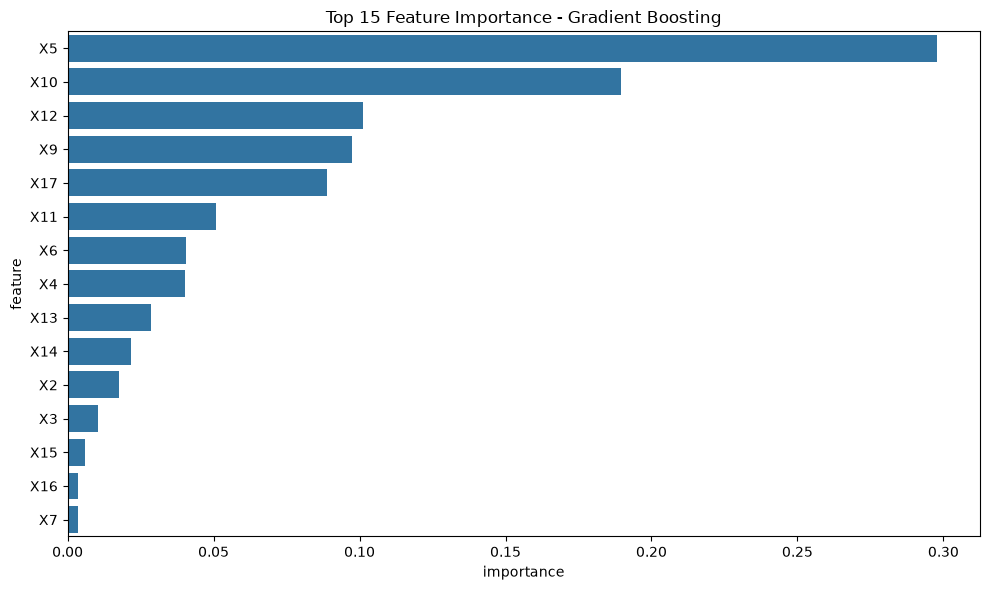

In [24]:
# ============================================================
# PREDICTIVE MODELLING 2: GRADIENT BOOSTING
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 2A. TRAINING MODEL
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_res, y_train_res)

print("✓ Gradient Boosting training selesai")

# 2B. PREDIKSI pada TEST SET
y_pred_gb = gb.predict(X_test)
y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

# 2C. CONFUSION MATRIX
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix - Gradient Boosting:")
print(cm_gb)

# 2D. EVALUASI PERFORMANCE
acc_gb = accuracy_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print("\n" + "="*50)
print("EVALUASI - Gradient Boosting")
print("="*50)
print(f"Accuracy : {acc_gb:.4f}")
print(f"Recall   : {rec_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")
print(f"ROC-AUC  : {roc_gb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

# 2E. ROC CURVE
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_proba_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, color='darkorange', lw=2.5,
         label=f'ROC Curve (AUC = {roc_gb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_gb, tpr_gb, alpha=0.15, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2F. FEATURE IMPORTANCE
importances_gb = pd.DataFrame({
    'feature': X_train_res.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_gb.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - Gradient Boosting')
plt.tight_layout()
plt.show()

# 2G. SIMPAN HASIL
hasil_gb = {
    'Model': 'Gradient Boosting',
    'Accuracy': acc_gb,
    'Recall': rec_gb,
    'Precision': prec_gb,
    'F1-Score': f1_gb,
    'ROC-AUC': roc_gb
}

G. Model Ensamble Learning (voting)

✓ Ensemble Learning (Voting) training selesai


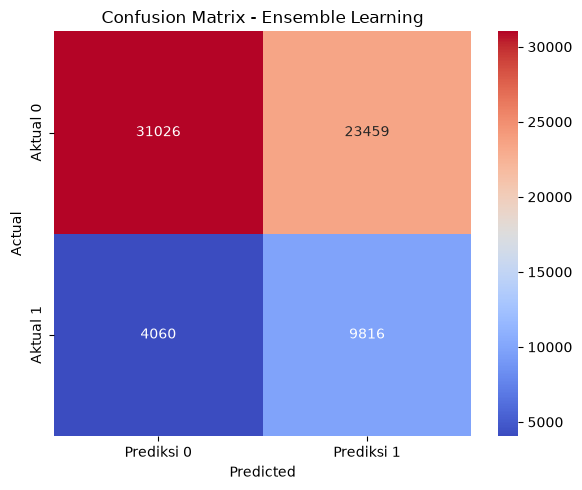

Confusion Matrix - Ensemble Learning:
[[31026 23459]
 [ 4060  9816]]

EVALUASI - Ensemble Learning (Voting)
Accuracy : 0.5974
Recall   : 0.7074
Precision: 0.2950
F1-Score : 0.4164
ROC-AUC  : 0.6905

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     54485
           1       0.29      0.71      0.42     13876

    accuracy                           0.60     68361
   macro avg       0.59      0.64      0.55     68361
weighted avg       0.76      0.60      0.64     68361



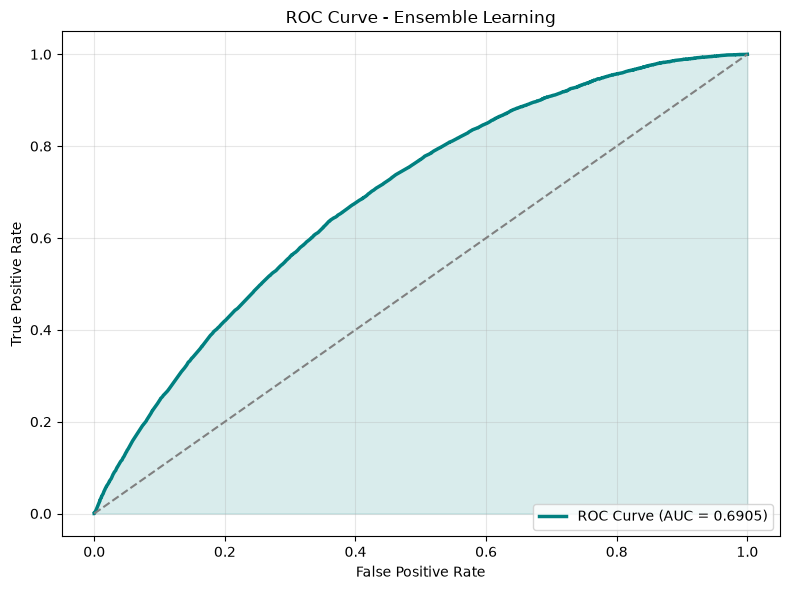

In [25]:
# ============================================================
# PREDICTIVE MODELLING 7: ENSEMBLE LEARNING (VOTING CLASSIFIER)
# Menggabungkan model terbaik: RF + XGBoost + LightGBM
# ============================================================

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

# 7A. DEFINISI MODEL-MODEL INDIVIDU
# (Pastikan model ini sudah ditraining, atau training ulang di sini)
rf_est = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_est = XGBClassifier(random_state=42, eval_metric='logloss')
lgbm_est = LGBMClassifier(random_state=42, verbose=-1)

# 7B. TRAINING ENSEMBLE (VOTING SOFT = berdasarkan probabilitas)
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_est),
        ('xgb', xgb_est),
        ('lgbm', lgbm_est)
    ],
    voting='soft'  # 'soft' pakai probabilitas, 'hard' pakai majority vote
)

ensemble.fit(X_train_res, y_train_res)

print("✓ Ensemble Learning (Voting) training selesai")

# 7C. PREDIKSI pada TEST SET
y_pred_ens = ensemble.predict(X_test)
y_pred_proba_ens = ensemble.predict_proba(X_test)[:, 1]

# 7D. CONFUSION MATRIX
cm_ens = confusion_matrix(y_test, y_pred_ens)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - Ensemble Learning')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion Matrix - Ensemble Learning:")
print(cm_ens)

# 7E. EVALUASI PERFORMANCE
acc_ens = accuracy_score(y_test, y_pred_ens)
rec_ens = recall_score(y_test, y_pred_ens)
prec_ens = precision_score(y_test, y_pred_ens)
f1_ens = f1_score(y_test, y_pred_ens)
roc_ens = roc_auc_score(y_test, y_pred_proba_ens)

print("\n" + "="*50)
print("EVALUASI - Ensemble Learning (Voting)")
print("="*50)
print(f"Accuracy : {acc_ens:.4f}")
print(f"Recall   : {rec_ens:.4f}")
print(f"Precision: {prec_ens:.4f}")
print(f"F1-Score : {f1_ens:.4f}")
print(f"ROC-AUC  : {roc_ens:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ens))

# 7F. ROC CURVE
fpr_ens, tpr_ens, _ = roc_curve(y_test, y_pred_proba_ens)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ens, tpr_ens, color='teal', lw=2.5,
         label=f'ROC Curve (AUC = {roc_ens:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_ens, tpr_ens, alpha=0.15, color='teal')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ensemble Learning')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7G. SIMPAN HASIL
hasil_ens = {
    'Model': 'Ensemble (Voting)',
    'Accuracy': acc_ens,
    'Recall': rec_ens,
    'Precision': prec_ens,
    'F1-Score': f1_ens,
    'ROC-AUC': roc_ens
}

#8. Perbandingan Model


PERBANDINGAN SEMUA MODEL
                   Model  Accuracy  Recall  Precision  F1-Score  ROC-AUC
     Logistic Regression    0.5875  0.7290     0.2927    0.4177   0.6933
           Random Forest    0.5892  0.6959     0.2881    0.4075   0.6752
       Gradient Boosting    0.5809  0.7375     0.2904    0.4167   0.6950
                 XGBoost    0.5926  0.7192     0.2941    0.4175   0.6924
                LightGBM    0.5941  0.7187     0.2949    0.4182   0.6945
                CatBoost    0.5957  0.7091     0.2943    0.4159   0.6898
SVM (Linear, 10% Sample)    0.3789  0.6428     0.1922    0.2959   0.4607
       Ensemble (Voting)    0.5974  0.7074     0.2950    0.4164   0.6905

--------------------------------------------------
MODEL TERBAIK PER METRIK:
--------------------------------------------------
Accuracy  : Ensemble (Voting)
Recall    : Gradient Boosting
Precision : Ensemble (Voting)
F1-Score  : LightGBM
ROC-AUC   : Gradient Boosting


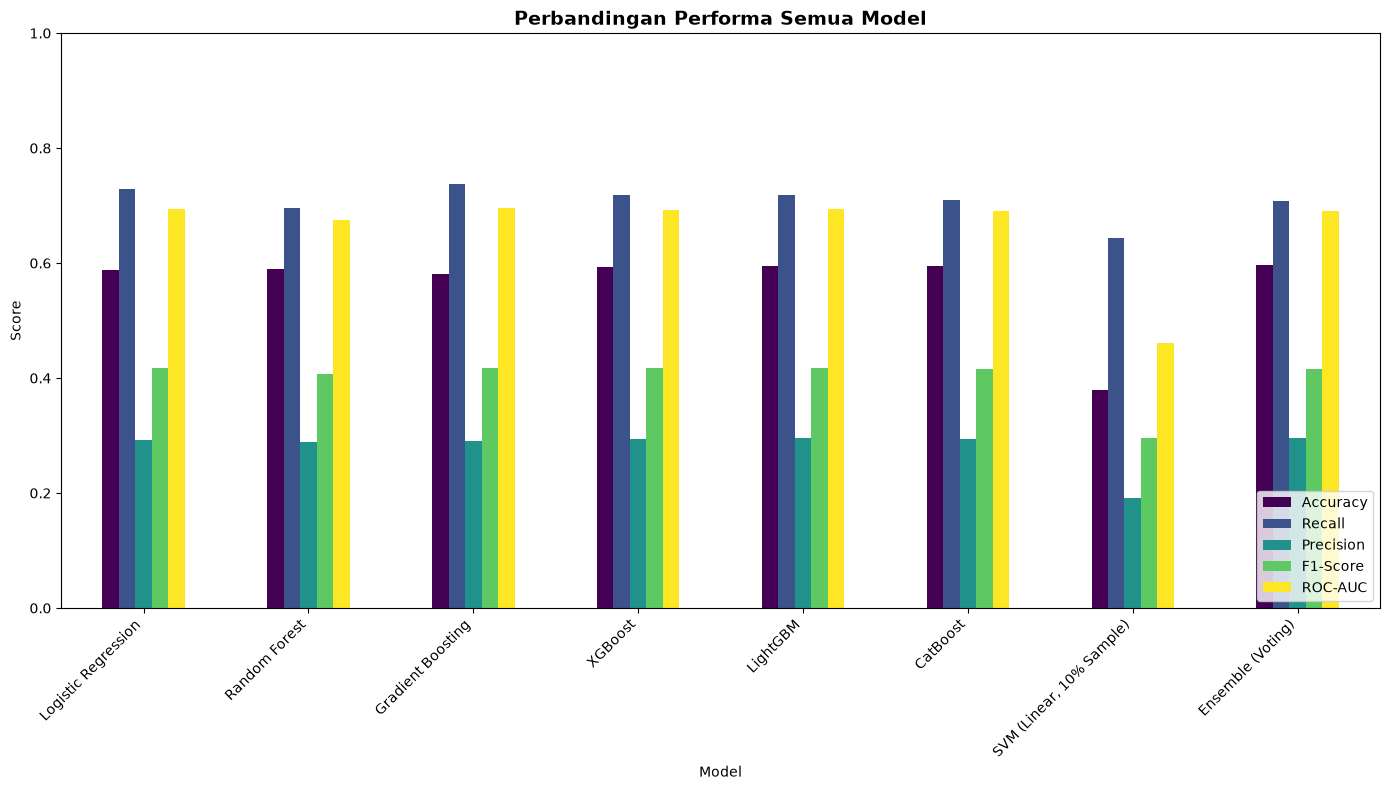

In [26]:
# ============================================================
# PERBANDINGAN SEMUA MODEL (Jalankan setelah semua model)
# ============================================================

# Kumpulkan semua hasil
semua_hasil = [
    hasil_logreg,  # dari Step 6
    hasil_rf,
    hasil_gb,
    hasil_xgb,
    hasil_lgbm,
    hasil_cat,
    hasil_svm,
    hasil_ens
]

df_perbandingan = pd.DataFrame(semua_hasil)

print("\n" + "="*80)
print("PERBANDINGAN SEMUA MODEL")
print("="*80)
print(df_perbandingan.round(4).to_string(index=False))

# Highlight model terbaik per metrik
print("\n" + "-"*50)
print("MODEL TERBAIK PER METRIK:")
print("-"*50)
print(f"Accuracy  : {df_perbandingan.loc[df_perbandingan['Accuracy'].idxmax(), 'Model']}")
print(f"Recall    : {df_perbandingan.loc[df_perbandingan['Recall'].idxmax(), 'Model']}")
print(f"Precision : {df_perbandingan.loc[df_perbandingan['Precision'].idxmax(), 'Model']}")
print(f"F1-Score  : {df_perbandingan.loc[df_perbandingan['F1-Score'].idxmax(), 'Model']}")
print(f"ROC-AUC   : {df_perbandingan.loc[df_perbandingan['ROC-AUC'].idxmax(), 'Model']}")

# Visualisasi perbandingan
df_perbandingan.set_index('Model').plot(kind='bar', figsize=(14, 8), colormap='viridis')
plt.title('Perbandingan Performa Semua Model', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#9. Hyperparameter Tuning + Feature Selection

A. Feature Selection dengan Boruta

2. XGBoost

BORUTA + XGBOOST
Fitur terpilih (17): ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17']
Fitur tentative (0): []

EVALUASI - XGBoost + BORUTA
Accuracy : 0.5926
Recall   : 0.7192
Precision: 0.2941
F1-Score : 0.4175
ROC-AUC  : 0.6924


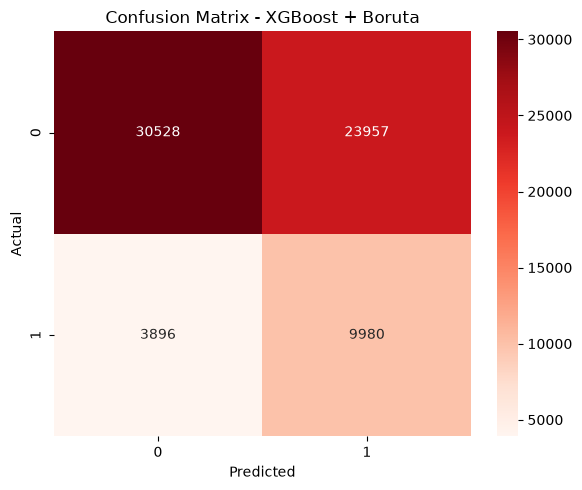

In [27]:
# ============================================================
# FEATURE SELECTION: BORUTA + XGBOOST
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from boruta import BorutaPy

# ------------------------------------------------------------
# 2A. DEFINISI MODEL UNTUK BORUTA
# ------------------------------------------------------------
xgb_boruta = XGBClassifier(random_state=42, eval_metric='logloss')

# ------------------------------------------------------------
# 2B. RUN BORUTA
# ------------------------------------------------------------
boruta_xgb = BorutaPy(
    xgb_boruta,
    n_estimators='auto',
    random_state=42,
    max_iter=50,
    verbose=0
)

boruta_xgb.fit(X_train_res.values, y_train_res.values)

# ------------------------------------------------------------
# 2C. AMBIL FITUR TERPILIH
# ------------------------------------------------------------
selected_xgb = X_train_res.columns[boruta_xgb.support_].tolist()
tentative_xgb = X_train_res.columns[boruta_xgb.support_weak_].tolist()

print("=" * 60)
print("BORUTA + XGBOOST")
print("=" * 60)
print(f"Fitur terpilih ({len(selected_xgb)}): {selected_xgb}")
print(f"Fitur tentative ({len(tentative_xgb)}): {tentative_xgb}")

# ------------------------------------------------------------
# 2D. TRAINING MODEL DENGAN FITUR TERPILIH
# ------------------------------------------------------------
X_train_xgb = X_train_res[selected_xgb]
X_test_xgb = X_test[selected_xgb]

xgb_selected = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_selected.fit(X_train_xgb, y_train_res)

# ------------------------------------------------------------
# 2E. PREDIKSI & EVALUASI
# ------------------------------------------------------------
y_pred_xgb = xgb_selected.predict(X_test_xgb)
y_pred_proba_xgb = xgb_selected.predict_proba(X_test_xgb)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

print("\n" + "=" * 60)
print("EVALUASI - XGBoost + BORUTA")
print("=" * 60)
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"F1-Score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_xgb:.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix - XGBoost + Boruta')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Simpan hasil
hasil_xgb_boruta = {
    'Model': 'XGBoost + Boruta',
    'N_Features': len(selected_xgb),
    'Accuracy': acc_xgb,
    'Recall': rec_xgb,
    'Precision': prec_xgb,
    'F1-Score': f1_xgb,
    'ROC-AUC': roc_xgb
}

1) Gradient boosting

BORUTA + GRADIENT BOOSTING
Fitur terpilih (17): ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17']
Fitur tentative (0): []
Fitur ditolak (0): []

EVALUASI - GB + BORUTA
Accuracy : 0.5809
Recall   : 0.7375
Precision: 0.2904
F1-Score : 0.4167
ROC-AUC  : 0.6950


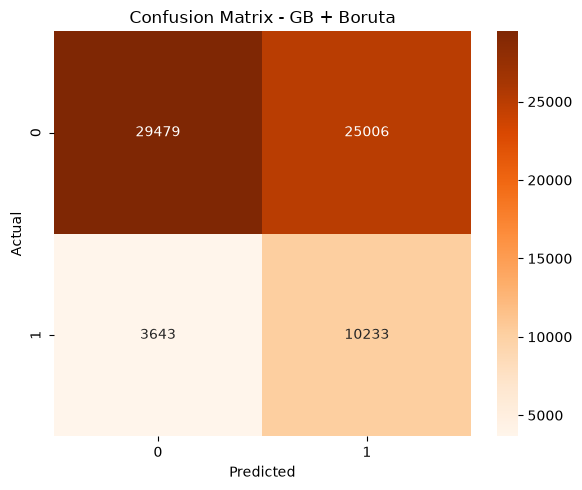

In [28]:
# ============================================================
# FEATURE SELECTION: BORUTA + GRADIENT BOOSTING
# ============================================================
import pandas as pd
import numpy as np
from boruta import BorutaPy
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1A. DEFINISI MODEL UNTUK BORUTA
# ------------------------------------------------------------
gb_boruta = GradientBoostingClassifier(n_estimators=100, random_state=42)

# ------------------------------------------------------------
# 1B. RUN BORUTA
# ------------------------------------------------------------
boruta_gb = BorutaPy(
    gb_boruta,
    n_estimators='auto',
    random_state=42,
    max_iter=50,
    verbose=0
)

# Fit Boruta (gunakan numpy array)
boruta_gb.fit(X_train_res.values, y_train_res.values)

# ------------------------------------------------------------
# 1C. AMBIL FITUR TERPILIH
# ------------------------------------------------------------
selected_gb = X_train_res.columns[boruta_gb.support_].tolist()
tentative_gb = X_train_res.columns[boruta_gb.support_weak_].tolist()

print("=" * 60)
print("BORUTA + GRADIENT BOOSTING")
print("=" * 60)
print(f"Fitur terpilih ({len(selected_gb)}): {selected_gb}")
print(f"Fitur tentative ({len(tentative_gb)}): {tentative_gb}")
print(f"Fitur ditolak ({len(X_train_res.columns) - len(selected_gb) - len(tentative_gb)}): "
      f"{[c for c in X_train_res.columns if c not in selected_gb + tentative_gb]}")

# ------------------------------------------------------------
# 1D. TRAINING MODEL DENGAN FITUR TERPILIH
# ------------------------------------------------------------
X_train_gb = X_train_res[selected_gb]
X_test_gb = X_test[selected_gb]

gb_selected = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_selected.fit(X_train_gb, y_train_res)

# ------------------------------------------------------------
# 1E. PREDIKSI & EVALUASI
# ------------------------------------------------------------
y_pred_gb = gb_selected.predict(X_test_gb)
y_pred_proba_gb = gb_selected.predict_proba(X_test_gb)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print("\n" + "=" * 60)
print("EVALUASI - GB + BORUTA")
print("=" * 60)
print(f"Accuracy : {acc_gb:.4f}")
print(f"Recall   : {rec_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"F1-Score : {f1_gb:.4f}")
print(f"ROC-AUC  : {roc_gb:.4f}")

# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Oranges')
plt.title('Confusion Matrix - GB + Boruta')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Simpan hasil
hasil_gb_boruta = {
    'Model': 'GB + Boruta',
    'N_Features': len(selected_gb),
    'Accuracy': acc_gb,
    'Recall': rec_gb,
    'Precision': prec_gb,
    'F1-Score': f1_gb,
    'ROC-AUC': roc_gb
}

4. ensemble voting

BORUTA + ENSEMBLE
Fitur terpilih (17): ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17']
Fitur tentative (0): []

EVALUASI - Ensemble + BORUTA
Accuracy : 0.5974
Recall   : 0.7074
Precision: 0.2950
F1-Score : 0.4164
ROC-AUC  : 0.6905


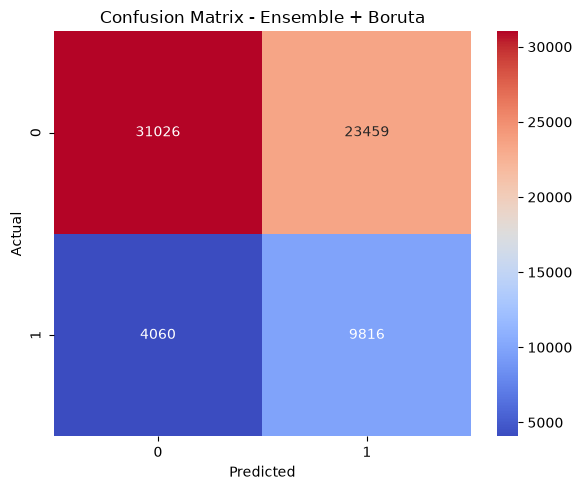

In [29]:
# ============================================================
# FEATURE SELECTION: BORUTA + ENSEMBLE (VOTING)
# ============================================================

from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 4A. DEFINISI MODEL UNTUK BORUTA (gunakan RF sebagai base)
# ------------------------------------------------------------
rf_boruta = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# ------------------------------------------------------------
# 4B. RUN BORUTA
# ------------------------------------------------------------
boruta_ens = BorutaPy(
    rf_boruta,
    n_estimators='auto',
    random_state=42,
    max_iter=50,
    verbose=0
)

boruta_ens.fit(X_train_res.values, y_train_res.values)

# ------------------------------------------------------------
# 4C. AMBIL FITUR TERPILIH
# ------------------------------------------------------------
selected_ens = X_train_res.columns[boruta_ens.support_].tolist()
tentative_ens = X_train_res.columns[boruta_ens.support_weak_].tolist()

# Fallback: Jika Boruta tidak memilih fitur, gunakan semua fitur
if not selected_ens and not tentative_ens:
    selected_ens = X_train_res.columns.tolist()
    print("WARNING: Boruta did not select any features. Falling back to all features.")
elif not selected_ens and tentative_ens:
    selected_ens = tentative_ens # Jika tidak ada fitur yang 'confirmed', gunakan yang 'tentative'
    print("WARNING: Boruta did not select 'confirmed' features. Using 'tentative' features.")

print("=" * 60)
print("BORUTA + ENSEMBLE")
print("=" * 60)
print(f"Fitur terpilih ({len(selected_ens)}): {selected_ens}")
print(f"Fitur tentative ({len(tentative_ens)}): {tentative_ens}")

# ------------------------------------------------------------
# 4D. TRAINING ENSEMBLE DENGAN FITUR TERPILIH
# ------------------------------------------------------------
X_train_ens = X_train_res[selected_ens]
X_test_ens = X_test[selected_ens]

# Definisi model individu
rf_est = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_est = XGBClassifier(random_state=42, eval_metric='logloss')
lgbm_est = LGBMClassifier(random_state=42, verbose=-1)

# Ensemble Voting
ensemble_selected = VotingClassifier(
    estimators=[
        ('rf', rf_est),
        ('xgb', xgb_est),
        ('lgbm', lgbm_est)
    ],
    voting='soft'
)

ensemble_selected.fit(X_train_ens, y_train_res)

# ------------------------------------------------------------
# 4E. PREDIKSI & EVALUASI
# ------------------------------------------------------------
y_pred_ens = ensemble_selected.predict(X_test_ens)
y_pred_proba_ens = ensemble_selected.predict_proba(X_test_ens)[:, 1]

acc_ens = accuracy_score(y_test, y_pred_ens)
rec_ens = recall_score(y_test, y_pred_ens)
prec_ens = precision_score(y_test, y_pred_ens)
f1_ens = f1_score(y_test, y_pred_ens)
roc_ens = roc_auc_score(y_test, y_pred_proba_ens)

print("\n" + "=" * 60)
print("EVALUASI - Ensemble + BORUTA")
print("=" * 60)
print(f"Accuracy : {acc_ens:.4f}")
print(f"Recall   : {rec_ens:.4f}")
print(f"Precision: {prec_ens:.4f}")
print(f"F1-Score : {f1_ens:.4f}")
print(f"ROC-AUC  : {roc_ens:.4f}")

# Confusion Matrix
cm_ens = confusion_matrix(y_test, y_pred_ens)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='coolwarm')
plt.title('Confusion Matrix - Ensemble + Boruta')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Simpan hasil
hasil_ens_boruta = {
    'Model': 'Ensemble + Boruta',
    'N_Features': len(selected_ens),
    'Accuracy': acc_ens,
    'Recall': rec_ens,
    'Precision': prec_ens,
    'F1-Score': f1_ens,
    'ROC-AUC': roc_ens
}

Perbandingan semua model


PERBANDINGAN MODEL + BORUTA
            Model  N_Features  Accuracy  Recall  Precision  F1-Score  ROC-AUC
      GB + Boruta          17    0.5809  0.7375     0.2904    0.4167   0.6950
 XGBoost + Boruta          17    0.5926  0.7192     0.2941    0.4175   0.6924
Ensemble + Boruta          17    0.5974  0.7074     0.2950    0.4164   0.6905

PERBANDINGAN: ASLI vs + BORUTA
            Model  F1_Original  F1_Boruta  ROC_Original  ROC_Boruta  N_Features_Original  N_Features_Boruta
Gradient Boosting       0.4167     0.4167        0.6950      0.6950                   17                 17
          XGBoost       0.4175     0.4175        0.6924      0.6924                   17                 17
Ensemble (Voting)       0.4164     0.4164        0.6905      0.6905                   17                 17


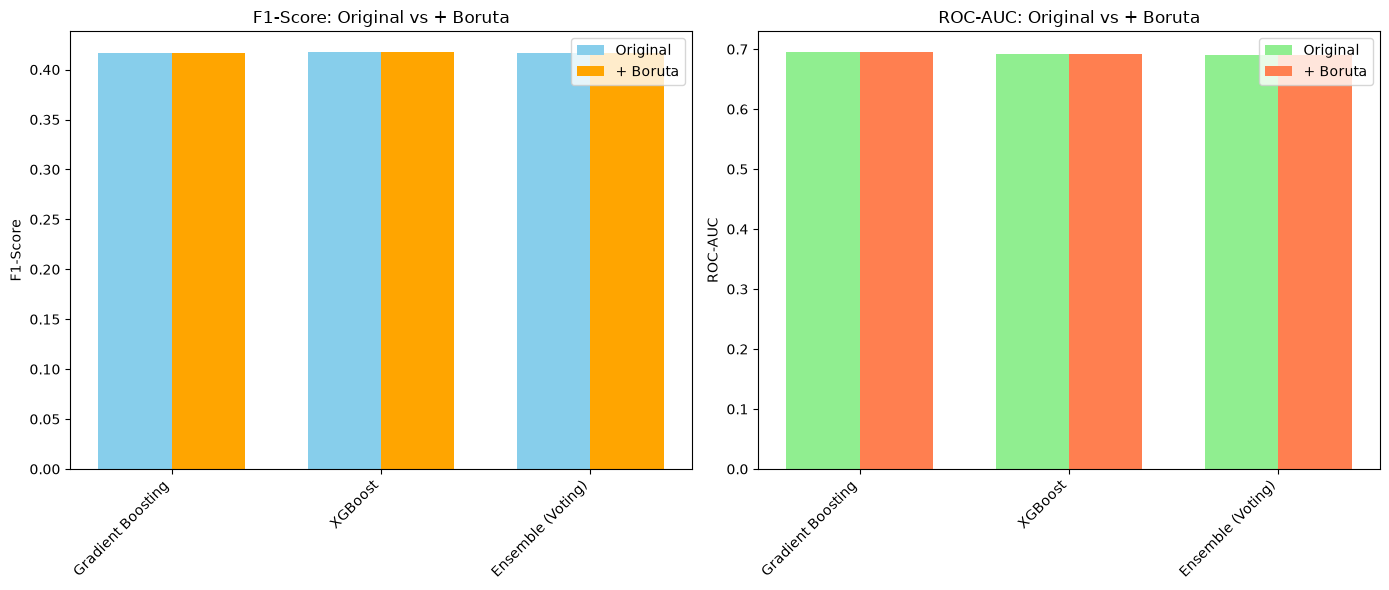

In [30]:
# ============================================================
# PERBANDINGAN: MODEL ASLI vs MODEL + BORUTA
# ============================================================

# Kumpulkan semua hasil Boruta
hasil_boruta_all = [
    hasil_gb_boruta,
    hasil_xgb_boruta,
    hasil_ens_boruta
]

df_boruta = pd.DataFrame(hasil_boruta_all)

print("\n" + "=" * 80)
print("PERBANDINGAN MODEL + BORUTA")
print("=" * 80)
print(df_boruta.round(4).to_string(index=False))

# Bandingkan dengan model asli (tanpa Boruta)
print("\n" + "=" * 80)
print("PERBANDINGAN: ASLI vs + BORUTA")
print("=" * 80)

comparison_data = []

# Define explicit mappings for original model names to their Boruta counterparts
models_to_compare_map = {
    'Gradient Boosting': 'GB + Boruta',
    'XGBoost': 'XGBoost + Boruta',
    'Ensemble (Voting)': 'Ensemble + Boruta' # Ensure this matches the name in df_perbandingan
}

for original_model_name, boruta_model_name_in_df_boruta in models_to_compare_map.items():
    original_row = df_perbandingan[df_perbandingan['Model'] == original_model_name]
    boruta_row = df_boruta[df_boruta['Model'] == boruta_model_name_in_df_boruta]

    if not original_row.empty and not boruta_row.empty:
        original = original_row.iloc[0]
        boruta = boruta_row.iloc[0]

        comparison_data.append({
            'Model': original_model_name,
            'F1_Original': original['F1-Score'],
            'F1_Boruta': boruta['F1-Score'],
            'ROC_Original': original['ROC-AUC'],
            'ROC_Boruta': boruta['ROC-AUC'],
            'N_Features_Original': len(X_train_res.columns), # Assuming original models used all features
            'N_Features_Boruta': boruta['N_Features']
        })
    else:
        print(f"Warning: Could not find comparison data for original model '{original_model_name}' or Boruta model '{boruta_model_name_in_df_boruta}'. Skipping.")

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.round(4).to_string(index=False))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(df_comparison))
width = 0.35

axes[0].bar(x - width/2, df_comparison['F1_Original'], width, label='Original', color='skyblue')
axes[0].bar(x + width/2, df_comparison['F1_Boruta'], width, label='+ Boruta', color='orange')
axes[0].set_ylabel('F1-Score')
axes[0].set_title('F1-Score: Original vs + Boruta')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_comparison['Model'], rotation=45, ha='right')
axes[0].legend()

axes[1].bar(x - width/2, df_comparison['ROC_Original'], width, label='Original', color='lightgreen')
axes[1].bar(x + width/2, df_comparison['ROC_Boruta'], width, label='+ Boruta', color='coral')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC: Original vs + Boruta')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_comparison['Model'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

C. PSO (Particle Swarm Optimization) untuk Hyperparameter

1. ensable voting

In [31]:
# ============================================================
# HYPERPARAMETER TUNING: PSO + ENSEMBLE VOTING
# Optimasi: Bobot (weights) untuk Soft Voting
# ============================================================

import numpy as np
from pyswarm import pso
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 2A. DEFINISI BASE MODELS (sudah fixed, akan di-tune bobotnya)
# ------------------------------------------------------------
# Gunakan parameter default yang bagus, atau hasil tuning sebelumnya
rf_base  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')
lgbm_base = LGBMClassifier(random_state=42, verbose=-1)

# ------------------------------------------------------------
# 2B. FUNGSI OBJEKTIF: OPTIMASI BOBOT ENSEMBLE
# ------------------------------------------------------------
def objective_ensemble(weights):
    """
    weights = [w_rf, w_xgb, w_lgbm]
    PSO minimize → return negative F1-Score
    """
    # Pastikan semua bobot positif
    w = np.maximum(weights, 0.01)

    # Normalize agar sum = 1 (opsional, tapi direkomendasikan)
    w = w / w.sum()

    ensemble = VotingClassifier(
        estimators=[
            ('rf', rf_base),
            ('xgb', xgb_base),
            ('lgbm', lgbm_base)
        ],
        voting='soft',
        weights=w.tolist()
    )

    # Cross-validation F1
    scores = cross_val_score(ensemble, X_train_res, y_train_res, cv=3, scoring='f1')

    return -scores.mean()

# ------------------------------------------------------------
# 2C. BATAS BOBOT
# ------------------------------------------------------------
# Bobot bebas 0.1 - 5.0 (akan di-normalize di dalam fungsi)
lb = [0.1, 0.1, 0.1]   # Lower bound
ub = [5.0, 5.0, 5.0]   # Upper bound

# ------------------------------------------------------------
# 2D. JALANKAN PSO
# ------------------------------------------------------------
print("=" * 60)
print("PSO OPTIMIZATION - ENSEMBLE VOTING WEIGHTS")
print("=" * 60)

result = pso(
    objective_ensemble,
    lb, ub,
    swarmsize=10,
    maxiter=10,
    debug=True
)

best_weights = result.x
best_score   = result.fun

# Normalisasi bobot final
best_weights = np.maximum(best_weights, 0.01)
best_weights = best_weights / best_weights.sum()

# ------------------------------------------------------------
# 2E. HASIL PSO
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("HASIL PSO - ENSEMBLE VOTING")
print("=" * 60)
print(f"Best F1-Score (CV): {-best_score:.4f}")
print(f"Optimal Weights (normalized):")
print(f"  Random Forest : {best_weights[0]:.4f}")
print(f"  XGBoost       : {best_weights[1]:.4f}")
print(f"  LightGBM      : {best_weights[2]:.4f}")
print(f"  Sum Check     : {best_weights.sum():.4f}")

# ------------------------------------------------------------
# 2F. TRAINING ENSEMBLE DENGAN BOBOT TERBAIK
# ------------------------------------------------------------
ensemble_pso = VotingClassifier(
    estimators=[
        ('rf', rf_base),
        ('xgb', xgb_base),
        ('lgbm', lgbm_base)
    ],
    voting='soft',
    weights=best_weights.tolist()
)

ensemble_pso.fit(X_train_res, y_train_res)

# ------------------------------------------------------------
# 2G. EVALUASI PADA TEST SET
# ------------------------------------------------------------
y_pred_ens_pso = ensemble_pso.predict(X_test)
y_proba_ens_pso = ensemble_pso.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

hasil_ens_pso = {
    'Model': 'Ensemble + PSO',
    'Weights': f"RF:{best_weights[0]:.2f}, XGB:{best_weights[1]:.2f}, LGBM:{best_weights[2]:.2f}",
    'Accuracy': accuracy_score(y_test, y_pred_ens_pso),
    'Recall': recall_score(y_test, y_pred_ens_pso),
    'Precision': precision_score(y_test, y_pred_ens_pso),
    'F1-Score': f1_score(y_test, y_pred_ens_pso),
    'ROC-AUC': roc_auc_score(y_test, y_proba_ens_pso)
}

print("\n" + "=" * 60)
print("EVALUASI ENSEMBLE + PSO")
print("=" * 60)
for k, v in hasil_ens_pso.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

PSO OPTIMIZATION - ENSEMBLE VOTING WEIGHTS

HASIL PSO - ENSEMBLE VOTING
Best F1-Score (CV): 0.6916
Optimal Weights (normalized):
  Random Forest : 0.6935
  XGBoost       : 0.0139
  LightGBM      : 0.2926
  Sum Check     : 1.0000

EVALUASI ENSEMBLE + PSO
Model: Ensemble + PSO
Weights: RF:0.69, XGB:0.01, LGBM:0.29
Accuracy: 0.5886
Recall: 0.7090
Precision: 0.2900
F1-Score: 0.4116
ROC-AUC: 0.6837


2. XGBoost

In [32]:
# ============================================================
# HYPERPARAMETER TUNING: PSO + XGBOOST
# ============================================================


import numpy as np
from pyswarm import pso
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1A. DEFINISI FUNGSI OBJEKTIF (yang akan di-minimize oleh PSO)
# ------------------------------------------------------------
def objective_xgb(params):
    """
    params = [n_estimators, max_depth, learning_rate, subsample, colsample_bytree]
    PSO minimize → kita return negative F1-Score
    """
    n_estimators = int(params[0])
    max_depth    = int(params[1])
    learning_rate = params[2]
    subsample     = params[3]
    colsample_bytree = params[4]

    # Pastikan parameter valid
    n_estimators = max(10, n_estimators)
    max_depth = max(2, max_depth)

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    )

    # Cross-validation dengan F1-Score (3-fold agar cepat)
    scores = cross_val_score(model, X_train_res, y_train_res, cv=3, scoring='f1')

    return -scores.mean()  # Negatif karena PSO minimize

# ------------------------------------------------------------
# 1B. BATAS PARAMETER (Lower Bound & Upper Bound)
# ------------------------------------------------------------
#         [n_estimators, max_depth, learning_rate, subsample, colsample_bytree]
lb = [50,   3,   0.01,  0.5,  0.5]   # Lower bound
ub = [300,  10,  0.30,  1.0,  1.0]   # Upper bound

# ------------------------------------------------------------
# 1C. JALANKAN PSO
# ------------------------------------------------------------
print("=" * 60)
print("PSO OPTIMIZATION - XGBOOST")
print("=" * 60)
print("Swarm Size: 10, Max Iter: 10 (bisa naikkan jika waktu cukup)")
print("-" * 60)

result = pso(
    objective_xgb,
    lb, ub,
    swarmsize=10,      # 10 partikel
    maxiter=10,        # 10 iterasi (naikkan ke 20-30 jika waktu cukup)
    debug=True         # Tampilkan progress
)
best_params = result.x
best_score   = result.fun

# ------------------------------------------------------------
# 1D. PARAMETER TERBAIK
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("HASIL PSO - XGBOOST")
print("=" * 60)
print(f"Best F1-Score (CV): {-best_score:.4f}")
print(f"Best Parameters:")
print(f"  n_estimators     : {int(best_params[0])}")
print(f"  max_depth        : {int(best_params[1])}")
print(f"  learning_rate    : {best_params[2]:.4f}")
print(f"  subsample        : {best_params[3]:.4f}")
print(f"  colsample_bytree : {best_params[4]:.4f}")

# ------------------------------------------------------------
# 1E. TRAINING XGBOOST DENGAN PARAMETER TERBAIK
# ------------------------------------------------------------
xgb_pso = XGBClassifier(
    n_estimators=int(best_params[0]),
    max_depth=int(best_params[1]),
    learning_rate=best_params[2],
    subsample=best_params[3],
    colsample_bytree=best_params[4],
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

xgb_pso.fit(X_train_res, y_train_res)

# ------------------------------------------------------------
# 1F. EVALUASI PADA TEST SET
# ------------------------------------------------------------
y_pred_xgb_pso = xgb_pso.predict(X_test)
y_proba_xgb_pso = xgb_pso.predict_proba(X_test)[:, 1]

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

hasil_xgb_pso = {
    'Model': 'XGBoost + PSO',
    'Accuracy': accuracy_score(y_test, y_pred_xgb_pso),
    'Recall': recall_score(y_test, y_pred_xgb_pso),
    'Precision': precision_score(y_test, y_pred_xgb_pso),
    'F1-Score': f1_score(y_test, y_pred_xgb_pso),
    'ROC-AUC': roc_auc_score(y_test, y_proba_xgb_pso)
}

print("\n" + "=" * 60)
print("EVALUASI XGBOOST + PSO")
print("=" * 60)
for k, v in hasil_xgb_pso.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

PSO OPTIMIZATION - XGBOOST
Swarm Size: 10, Max Iter: 10 (bisa naikkan jika waktu cukup)
------------------------------------------------------------

HASIL PSO - XGBOOST
Best F1-Score (CV): 0.6896
Best Parameters:
  n_estimators     : 162
  max_depth        : 10
  learning_rate    : 0.2931
  subsample        : 0.7197
  colsample_bytree : 0.7242

EVALUASI XGBOOST + PSO
Model: XGBoost + PSO
Accuracy: 0.5909
Recall: 0.7049
Precision: 0.2906
F1-Score: 0.4116
ROC-AUC: 0.6820


Perbandingan PSO


PERBANDINGAN: DEFAULT vs PSO-TUNED
             Model  F1-Score  ROC-AUC  Accuracy  Recall  Precision                      Weights
 XGBoost (Default)    0.4175   0.6924       NaN     NaN        NaN                          NaN
     XGBoost + PSO    0.4116   0.6820    0.5909  0.7049     0.2906                          NaN
Ensemble (Default)    0.4164   0.6905       NaN     NaN        NaN                          NaN
    Ensemble + PSO    0.4116   0.6837    0.5886  0.7090     0.2900 RF:0.69, XGB:0.01, LGBM:0.29


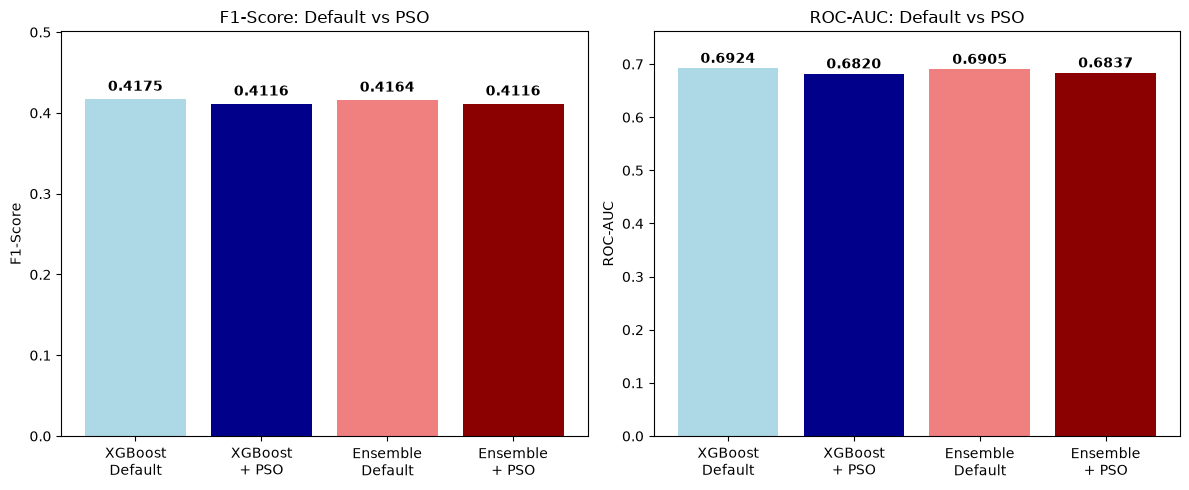

In [33]:
# ============================================================
# PERBANDINGAN: DEFAULT vs PSO-TUNED
# ============================================================

import pandas as pd

# Kumpulkan hasil (ambil dari hasil sebelumnya + PSO)
comparison = pd.DataFrame([
    # Default models (dari hasil sebelumnya)
    {'Model': 'XGBoost (Default)', 'F1-Score': 0.4175, 'ROC-AUC': 0.6924},  # ganti dengan nilai Anda
    # PSO models
    hasil_xgb_pso,
    {'Model': 'Ensemble (Default)', 'F1-Score': 0.4164, 'ROC-AUC': 0.6905},  # ganti dengan nilai Anda
    hasil_ens_pso
])

print("\n" + "=" * 70)
print("PERBANDINGAN: DEFAULT vs PSO-TUNED")
print("=" * 70)
print(comparison.round(4).to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

x_labels = ['XGBoost\nDefault', 'XGBoost\n+ PSO', 'Ensemble\nDefault', 'Ensemble\n+ PSO']
f1_vals = comparison['F1-Score'].values
roc_vals = comparison['ROC-AUC'].values

colors = ['lightblue', 'darkblue', 'lightcoral', 'darkred']

ax[0].bar(x_labels, f1_vals, color=colors)
ax[0].set_ylabel('F1-Score')
ax[0].set_title('F1-Score: Default vs PSO')
ax[0].set_ylim(0, max(f1_vals)*1.2)
for i, v in enumerate(f1_vals):
    ax[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

ax[1].bar(x_labels, roc_vals, color=colors)
ax[1].set_ylabel('ROC-AUC')
ax[1].set_title('ROC-AUC: Default vs PSO')
ax[1].set_ylim(0, max(roc_vals)*1.1)
for i, v in enumerate(roc_vals):
    ax[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

B. Hyperparameter Tuning dengan GridSearchCV

1. XGBoost

RANDOMIZEDSEARCHCV - XGBOOST
Fitting 3 folds for each of 30 candidates, totalling 90 fits

HASIL RANDOMIZEDSEARCHCV - XGBOOST
Best F1-Score (CV): 0.6886

Best Parameters:
  subsample           : 0.6
  reg_lambda          : 10
  reg_alpha           : 0.1
  n_estimators        : 500
  min_child_weight    : 3
  max_depth           : 15
  learning_rate       : 0.2
  gamma               : 0.1
  colsample_bytree    : 0.9

✓ XGBoost dengan parameter terbaik training selesai

EVALUASI XGBOOST + RANDOMSEARCHCV
Model       : XGBoost + RandomSearchCV
Accuracy    : 0.5947
Recall      : 0.6921
Precision   : 0.2907
F1-Score    : 0.4094
ROC-AUC     : 0.6787


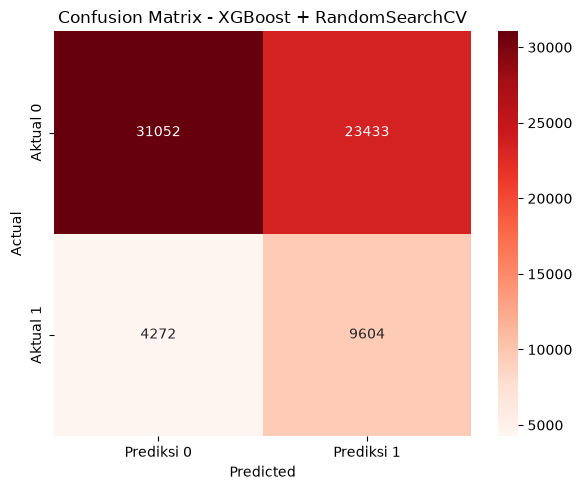

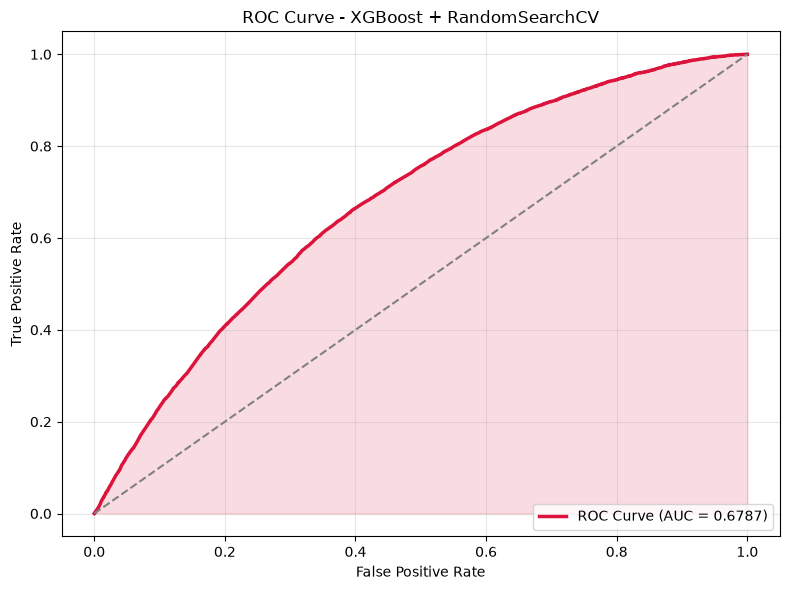


✓ Hasil XGBoost + RandomSearchCV tersimpan


In [34]:
# ============================================================
# HYPERPARAMETER TUNING: RANDOMIZEDSEARCHCV + XGBOOST
# ============================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1A. DEFINISI PARAMETER DISTRIBUTION
# ------------------------------------------------------------
param_dist_xgb = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.5, 1],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 2, 5, 10]
}

# ------------------------------------------------------------
# 1B. RANDOMIZED SEARCH CV
# ------------------------------------------------------------
print("=" * 60)
print("RANDOMIZEDSEARCHCV - XGBOOST")
print("=" * 60)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,              # 30 kombinasi random (bisa naikkan ke 50-100)
    cv=3,                   # 3-fold cross-validation
    scoring='f1',           # Optimasi F1-Score (bisa ganti 'roc_auc')
    n_jobs=-1,              # Parallel processing
    random_state=42,
    verbose=1
)

random_search_xgb.fit(X_train_res, y_train_res)

# ------------------------------------------------------------
# 1C. HASIL TUNING
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("HASIL RANDOMIZEDSEARCHCV - XGBOOST")
print("=" * 60)
print(f"Best F1-Score (CV): {random_search_xgb.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in random_search_xgb.best_params_.items():
    print(f"  {param:20s}: {value}")

# ------------------------------------------------------------
# 1D. TRAINING ULANG DENGAN PARAMETER TERBAIK
# ------------------------------------------------------------
best_xgb = random_search_xgb.best_estimator_
best_xgb.fit(X_train_res, y_train_res)

print("\n✓ XGBoost dengan parameter terbaik training selesai")

# ------------------------------------------------------------
# 1E. EVALUASI PADA TEST SET
# ------------------------------------------------------------
y_pred_xgb_rs = best_xgb.predict(X_test)
y_pred_proba_xgb_rs = best_xgb.predict_proba(X_test)[:, 1]

acc_xgb_rs = accuracy_score(y_test, y_pred_xgb_rs)
rec_xgb_rs = recall_score(y_test, y_pred_xgb_rs)
prec_xgb_rs = precision_score(y_test, y_pred_xgb_rs)
f1_xgb_rs = f1_score(y_test, y_pred_xgb_rs)
roc_xgb_rs = roc_auc_score(y_test, y_pred_proba_xgb_rs)

hasil_xgb_rs = {
    'Model': 'XGBoost + RandomSearchCV',
    'Accuracy': acc_xgb_rs,
    'Recall': rec_xgb_rs,
    'Precision': prec_xgb_rs,
    'F1-Score': f1_xgb_rs,
    'ROC-AUC': roc_xgb_rs
}

print("\n" + "=" * 60)
print("EVALUASI XGBOOST + RANDOMSEARCHCV")
print("=" * 60)
for k, v in hasil_xgb_rs.items():
    if isinstance(v, float):
        print(f"{k:12s}: {v:.4f}")
    else:
        print(f"{k:12s}: {v}")

# ------------------------------------------------------------
# 1F. CONFUSION MATRIX
# ------------------------------------------------------------
cm_xgb_rs = confusion_matrix(y_test, y_pred_xgb_rs)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_rs, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - XGBoost + RandomSearchCV')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 1G. ROC CURVE
# ------------------------------------------------------------
from sklearn.metrics import roc_curve

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb_rs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='crimson', lw=2.5,
         label=f'ROC Curve (AUC = {roc_xgb_rs:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_xgb, tpr_xgb, alpha=0.15, color='crimson')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost + RandomSearchCV')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 1H. SIMPAN HASIL
# ------------------------------------------------------------
print("\n✓ Hasil XGBoost + RandomSearchCV tersimpan")

2.ensemble

RANDOMIZEDSEARCHCV - ENSEMBLE VOTING
Fitting 3 folds for each of 20 candidates, totalling 60 fits

HASIL RANDOMIZEDSEARCHCV - ENSEMBLE VOTING
Best F1-Score (CV): 0.6894

Best Parameters:
  xgb__n_estimators        : 200
  xgb__max_depth           : 5
  xgb__learning_rate       : 0.1
  weights                  : [2, 1, 1]
  rf__n_estimators         : 200
  rf__min_samples_split    : 2
  rf__max_depth            : None
  lgbm__n_estimators       : 50
  lgbm__max_depth          : -1
  lgbm__learning_rate      : 0.2

✓ Ensemble Voting dengan parameter terbaik training selesai

EVALUASI ENSEMBLE + RANDOMSEARCHCV
Model       : Ensemble + RandomSearchCV
Accuracy    : 0.5923
Recall      : 0.7104
Precision   : 0.2924
F1-Score    : 0.4143
ROC-AUC     : 0.6884


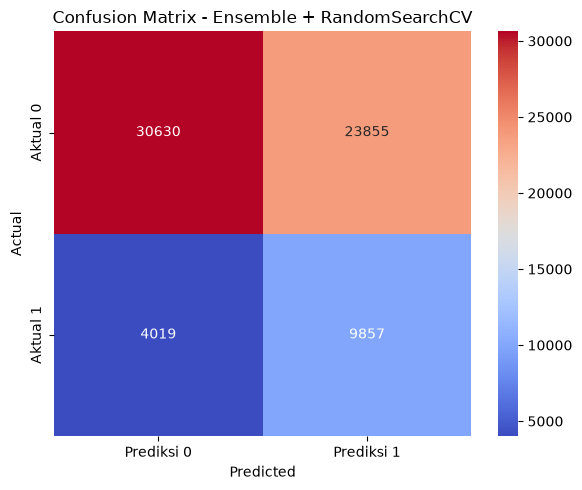

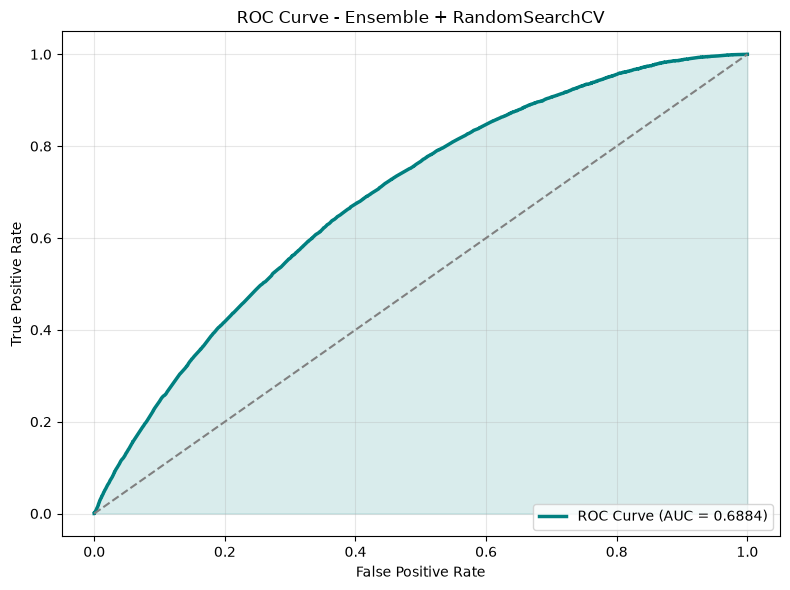


✓ Hasil Ensemble + RandomSearchCV tersimpan


In [35]:
# ============================================================
# HYPERPARAMETER TUNING: RANDOMIZEDSEARCHCV + ENSEMBLE VOTING
# Optimasi: Bobot + Parameter base models
# ============================================================

from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 2A. DEFINISI BASE MODELS (dengan parameter default)
# ------------------------------------------------------------
rf_est = RandomForestClassifier(random_state=42, n_jobs=-1)
xgb_est = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
lgbm_est = LGBMClassifier(random_state=42, verbose=-1)

# ------------------------------------------------------------
# 2B. DEFINISI ENSEMBLE DENGAN PARAMETER YANG AKAN DI-TUNE
# ------------------------------------------------------------
# Kita tune: weights + beberapa parameter base models

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_est),
        ('xgb', xgb_est),
        ('lgbm', lgbm_est)
    ],
    voting='soft'
)

# ------------------------------------------------------------
# 2C. PARAMETER DISTRIBUTION
# ------------------------------------------------------------
# Parameter untuk VotingClassifier + base models
param_dist_ens = {
    # Bobot ensemble (akan di-normalize)
    'weights': [[1, 1, 1], [2, 1, 1], [1, 2, 1], [1, 1, 2],
                [2, 2, 1], [1, 2, 2], [2, 1, 2], [3, 2, 1]],

    # Random Forest params
    'rf__n_estimators': [50, 100, 200],
    'rf__max_depth': [5, 10, 15, None],
    'rf__min_samples_split': [2, 5, 10],

    # XGBoost params
    'xgb__n_estimators': [50, 100, 200],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.05, 0.1, 0.2],

    # LightGBM params
    'lgbm__n_estimators': [50, 100, 200],
    'lgbm__max_depth': [3, 5, 7, -1],
    'lgbm__learning_rate': [0.05, 0.1, 0.2]
}

# ------------------------------------------------------------
# 2D. RANDOMIZED SEARCH CV
# ------------------------------------------------------------
print("=" * 60)
print("RANDOMIZEDSEARCHCV - ENSEMBLE VOTING")
print("=" * 60)

random_search_ens = RandomizedSearchCV(
    estimator=ensemble,
    param_distributions=param_dist_ens,
    n_iter=20,              # 20 kombinasi (bisa naikkan)
    cv=3,                   # 3-fold CV
    scoring='f1',           # Optimasi F1
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_ens.fit(X_train_res, y_train_res)

# ------------------------------------------------------------
# 2E. HASIL TUNING
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("HASIL RANDOMIZEDSEARCHCV - ENSEMBLE VOTING")
print("=" * 60)
print(f"Best F1-Score (CV): {random_search_ens.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in random_search_ens.best_params_.items():
    print(f"  {param:25s}: {value}")

# ------------------------------------------------------------
# 2F. TRAINING ULANG DENGAN PARAMETER TERBAIK
# ------------------------------------------------------------
best_ensemble = random_search_ens.best_estimator_
best_ensemble.fit(X_train_res, y_train_res)

print("\n✓ Ensemble Voting dengan parameter terbaik training selesai")

# ------------------------------------------------------------
# 2G. EVALUASI PADA TEST SET
# ------------------------------------------------------------
y_pred_ens_rs = best_ensemble.predict(X_test)
y_pred_proba_ens_rs = best_ensemble.predict_proba(X_test)[:, 1]

acc_ens_rs = accuracy_score(y_test, y_pred_ens_rs)
rec_ens_rs = recall_score(y_test, y_pred_ens_rs)
prec_ens_rs = precision_score(y_test, y_pred_ens_rs)
f1_ens_rs = f1_score(y_test, y_pred_ens_rs)
roc_ens_rs = roc_auc_score(y_test, y_pred_proba_ens_rs)

hasil_ens_rs = {
    'Model': 'Ensemble + RandomSearchCV',
    'Accuracy': acc_ens_rs,
    'Recall': rec_ens_rs,
    'Precision': prec_ens_rs,
    'F1-Score': f1_ens_rs,
    'ROC-AUC': roc_ens_rs
}

print("\n" + "=" * 60)
print("EVALUASI ENSEMBLE + RANDOMSEARCHCV")
print("=" * 60)
for k, v in hasil_ens_rs.items():
    if isinstance(v, float):
        print(f"{k:12s}: {v:.4f}")
    else:
        print(f"{k:12s}: {v}")

# ------------------------------------------------------------
# 2H. CONFUSION MATRIX
# ------------------------------------------------------------
cm_ens_rs = confusion_matrix(y_test, y_pred_ens_rs)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_ens_rs, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Prediksi 0', 'Prediksi 1'],
            yticklabels=['Aktual 0', 'Aktual 1'])
plt.title('Confusion Matrix - Ensemble + RandomSearchCV')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2I. ROC CURVE
# ------------------------------------------------------------
from sklearn.metrics import roc_curve

fpr_ens, tpr_ens, _ = roc_curve(y_test, y_pred_proba_ens_rs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ens, tpr_ens, color='teal', lw=2.5,
         label=f'ROC Curve (AUC = {roc_ens_rs:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.fill_between(fpr_ens, tpr_ens, alpha=0.15, color='teal')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ensemble + RandomSearchCV')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2J. SIMPAN HASIL
# ------------------------------------------------------------
print("\n✓ Hasil Ensemble + RandomSearchCV tersimpan")

Perbandingan


PERBANDINGAN: DEFAULT vs RANDOMSEARCHCV
                    Model  F1-Score  ROC-AUC  Accuracy  Recall  Precision
        XGBoost (Default)    0.4175   0.6924       NaN     NaN        NaN
 XGBoost + RandomSearchCV    0.4094   0.6787    0.5947  0.6921     0.2907
       Ensemble (Default)    0.4164   0.6905       NaN     NaN        NaN
Ensemble + RandomSearchCV    0.4143   0.6884    0.5923  0.7104     0.2924


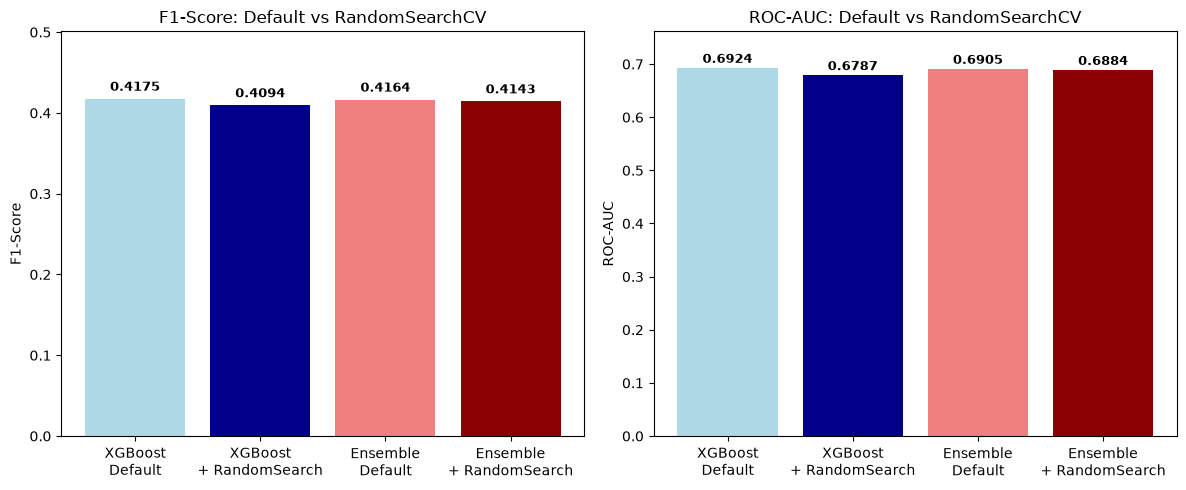

In [36]:
# ============================================================
# PERBANDINGAN: DEFAULT vs RANDOMSEARCHCV
# ============================================================

import pandas as pd

# Kumpulkan hasil (ganti dengan nilai sebenarnya dari hasil sebelumnya)
comparison_rs = pd.DataFrame([
    {'Model': 'XGBoost (Default)', 'F1-Score': 0.4175, 'ROC-AUC': 0.6924},
    hasil_xgb_rs,
    {'Model': 'Ensemble (Default)', 'F1-Score': 0.4164, 'ROC-AUC': 0.6905},
    hasil_ens_rs
])

print("\n" + "=" * 70)
print("PERBANDINGAN: DEFAULT vs RANDOMSEARCHCV")
print("=" * 70)
print(comparison_rs.round(4).to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

x_labels = ['XGBoost\nDefault', 'XGBoost\n+ RandomSearch',
            'Ensemble\nDefault', 'Ensemble\n+ RandomSearch']
f1_vals = comparison_rs['F1-Score'].values
roc_vals = comparison_rs['ROC-AUC'].values

colors = ['lightblue', 'darkblue', 'lightcoral', 'darkred']

ax[0].bar(x_labels, f1_vals, color=colors)
ax[0].set_ylabel('F1-Score')
ax[0].set_title('F1-Score: Default vs RandomSearchCV')
ax[0].set_ylim(0, max(f1_vals)*1.2)
for i, v in enumerate(f1_vals):
    ax[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

ax[1].bar(x_labels, roc_vals, color=colors)
ax[1].set_ylabel('ROC-AUC')
ax[1].set_title('ROC-AUC: Default vs RandomSearchCV')
ax[1].set_ylim(0, max(roc_vals)*1.1)
for i, v in enumerate(roc_vals):
    ax[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Perbandingan Semua Model

TABEL PERBANDINGAN SEMUA MODEL (15 Konfigurasi)
                    Model  Accuracy  Recall  Precision  F1-Score  ROC-AUC
                 LightGBM    0.5941  0.7187     0.2949    0.4182   0.6945
      Logistic Regression    0.5875  0.7290     0.2927    0.4177   0.6933
                  XGBoost    0.5926  0.7192     0.2941    0.4175   0.6924
         XGBoost + Boruta    0.5926  0.7192     0.2941    0.4175   0.6924
        Gradient Boosting    0.5809  0.7375     0.2904    0.4167   0.6950
              GB + Boruta    0.5809  0.7375     0.2904    0.4167   0.6950
        Ensemble (Voting)    0.5974  0.7074     0.2950    0.4164   0.6905
        Ensemble + Boruta    0.5974  0.7074     0.2950    0.4164   0.6905
                 CatBoost    0.5957  0.7091     0.2943    0.4159   0.6898
Ensemble + RandomSearchCV    0.5923  0.7104     0.2924    0.4143   0.6884
           Ensemble + PSO    0.5886  0.7090     0.2900    0.4116   0.6837
            XGBoost + PSO    0.5909  0.7049     0.2906    0.4116

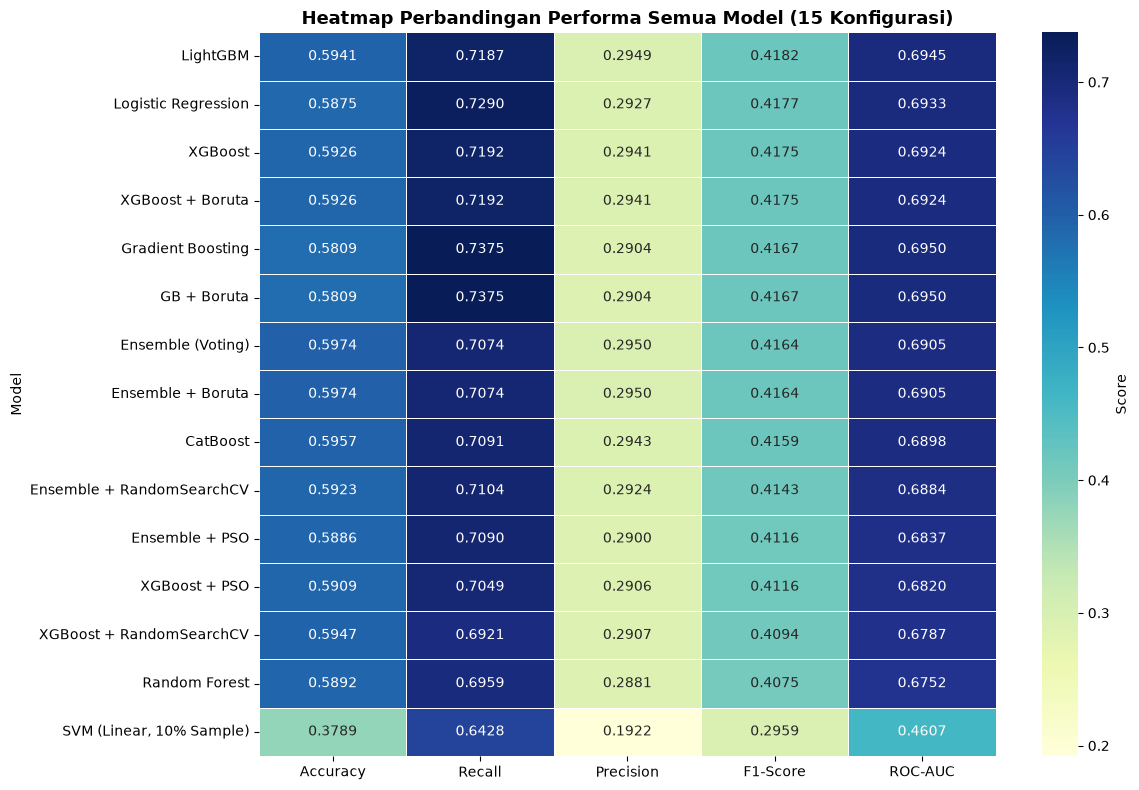

In [37]:
# ============================================================
# TAMPILKAN PERBANDINGAN SEMUA MODEL 
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Kolom standar yang digunakan semua model
kolom_standar = ['Model', 'Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']

# Kumpulkan SEMUA hasil dari seluruh tahap
semua_model = [
    # --- Base models (Section 6 & 7) ---
    hasil_logreg,
    hasil_rf,
    hasil_gb,
    hasil_xgb,
    hasil_lgbm,
    hasil_cat,
    hasil_svm,
    hasil_ens,
    # --- Boruta feature selection (Section 9A) ---
    hasil_gb_boruta,
    hasil_xgb_boruta,
    hasil_ens_boruta,
    # --- PSO tuning (Section 9C) ---
    hasil_xgb_pso,
    hasil_ens_pso,
    # --- RandomizedSearchCV tuning (Section 9B) ---
    hasil_xgb_rs,
    hasil_ens_rs
]

# Bangun DataFrame, ambil hanya kolom standar (abaikan 'Weights', 'N_Features', dll.)
df_semua = pd.DataFrame(semua_model)[kolom_standar]

# Urutkan berdasarkan F1-Score (descending)
df_semua = df_semua.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("=" * 85)
print("TABEL PERBANDINGAN SEMUA MODEL (15 Konfigurasi)")
print("=" * 85)
print(df_semua.round(4).to_string(index=False))

# --- Ranking top-3 per metrik ---
print("\n" + "-" * 50)
print("RANKING MODEL TERBAIK PER METRIK (Top 3):")
print("-" * 50)
for metrik in ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']:
    top3 = df_semua.sort_values(by=metrik, ascending=False).head(3)
    print(f"\n{metrik}:")
    for rank, (_, row) in enumerate(top3.iterrows(), 1):
        print(f"  {rank}. {row['Model']:<30s} : {row[metrik]:.4f}")

# --- Heatmap perbandingan ---
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_semua.set_index('Model'),
    annot=True, fmt='.4f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Score'},
    linewidths=0.5
)
plt.title('Heatmap Perbandingan Performa Semua Model (15 Konfigurasi)',
          fontsize=13, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()